In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
import numpy as np
from scipy.interpolate import interp1d
import re
mpl.rcParams['svg.fonttype'] = 'none'
from scipy.optimize import root_scalar


### 기존 파일 CSV로 변환

In [ ]:
# # 1. 파일 경로 설정
# file_path = 'curva_pbc_20250727.1'

In [12]:
# # 파일 읽기(이전과 동일)
# df = pd.read_csv(file_path, sep=';', encoding='latin-1', skiprows=2)

# # 1) 콘솔에서 간단히 출력
# print(df.head())

# # 1) 모든 행·열 출력하기 (콘솔용)
# pd.set_option('display.max_rows', None)    # 행 제한 해제
# pd.set_option('display.max_columns', None) # 열 제한 해제

# print(df)  # or print(df.to_string())

   Periodo       Fecha Pais  Unidad Tipo Oferta Potencia Compra/Venta  \
0      1.0  27/07/2025   MI     NaN           C                   7,0   
1      1.0  27/07/2025   MI     NaN           C                 203,4   
2      1.0  27/07/2025   MI     NaN           C                 414,2   
3      1.0  27/07/2025   MI     NaN           C                   0,1   
4      1.0  27/07/2025   MI     NaN           C                 293,8   

  Precio Compra/Venta Ofertada (O)/Casada (C) Tipología de Oferta  Unnamed: 9  
0            1.500,00                       O                   S         NaN  
1            1.500,00                       O                   S         NaN  
2            1.500,00                       O                   S         NaN  
3              800,00                       O                   S         NaN  
4              501,00                       O                   S         NaN  


In [ ]:
df.to_csv('all_data.csv', index=False)

In [73]:
# 1) 바꿀 헤더명 매핑 딕셔너리
mapping = {
    'Periodo':      'Time Period',
    'Fecha':        'Date',
    'Precio Compra/Venta':         'Price',
    'Potencia Compra/Venta':       'Amount',
    'Tipo Oferta':  'GC'
}


# 1) 마지막 점만 유지하는 함수
def keep_last_dot(s: str) -> str:
    # '1.800.3' → '1800.3'
    return re.sub(r'\.(?=[^.]*\.)', '', s)

# 2) 7/20 부터 7/27 까지 반복
for day in range(20, 28):
    date_str = f"202507{day:02d}"
    in_file  = f"curva_pbc_{date_str}.1"
    out_file = f"curve_{date_str}.csv"

    if os.path.isfile(in_file):
        # 읽기
        df = pd.read_csv(
            in_file,
            sep=';',
            encoding='latin-1',
            skiprows=2
        )

        # 헤더명 변경 (매핑에 없는 컬럼은 그대로)
        df = df.rename(columns=mapping)

        # 저장 (utf-8-sig: Excel 호환)
        df.to_csv(
            out_file,
            index=False,
            encoding='utf-8-sig'
        )
        print(f"✔ Converted: {in_file} → {out_file}")
    else:
        print(f"⚠ File not found: {in_file}")


✔ Converted: curva_pbc_20250720.1 → curve_20250720.csv
✔ Converted: curva_pbc_20250721.1 → curve_20250721.csv
✔ Converted: curva_pbc_20250722.1 → curve_20250722.csv
✔ Converted: curva_pbc_20250723.1 → curve_20250723.csv
✔ Converted: curva_pbc_20250724.1 → curve_20250724.csv
✔ Converted: curva_pbc_20250725.1 → curve_20250725.csv
✔ Converted: curva_pbc_20250726.1 → curve_20250726.csv
✔ Converted: curva_pbc_20250727.1 → curve_20250727.csv


### 기존 파일 전처리 (콤마 필터링)

In [77]:
pattern = r'\.(?=[^.]*\.)'

for day in range(20, 28):
    date_str = f"202507{day:02d}"
    in_file  = f"curve_{date_str}.csv"
    out_file = f"filteredcurve_{date_str}.csv"

    try:
        # 1) CSV 읽기 (기본 구분자 ',' 사용)
        df = pd.read_csv(in_file, sep=',', encoding='utf-8-sig')
        
        # 2) Price/Amount 문자열 처리
        df['Price']  = (df['Price'].astype(str)
                             .str.replace(',', '.', regex=False)
                             .apply(lambda s: re.sub(pattern, '', s)))
        df['Amount'] = (df['Amount'].astype(str)
                             .str.replace(',', '.', regex=False)
                             .apply(lambda s: re.sub(pattern, '', s)))
        
        # 3) Numeric 타입 변환
        df['Price']  = pd.to_numeric(df['Price'],  errors='coerce')
        df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
        
        # 4) 저장
        df.to_csv(out_file, sep=',', index=False, encoding='utf-8-sig')
        print(f"✔ {in_file} → {out_file}")
    except FileNotFoundError:
        print(f"⚠ 파일이 없습니다: {in_file}")

✔ curve_20250720.csv → filteredcurve_20250720.csv
✔ curve_20250721.csv → filteredcurve_20250721.csv
✔ curve_20250722.csv → filteredcurve_20250722.csv
✔ curve_20250723.csv → filteredcurve_20250723.csv
✔ curve_20250724.csv → filteredcurve_20250724.csv
✔ curve_20250725.csv → filteredcurve_20250725.csv
✔ curve_20250726.csv → filteredcurve_20250726.csv
✔ curve_20250727.csv → filteredcurve_20250727.csv


### Supply and Demand Curve

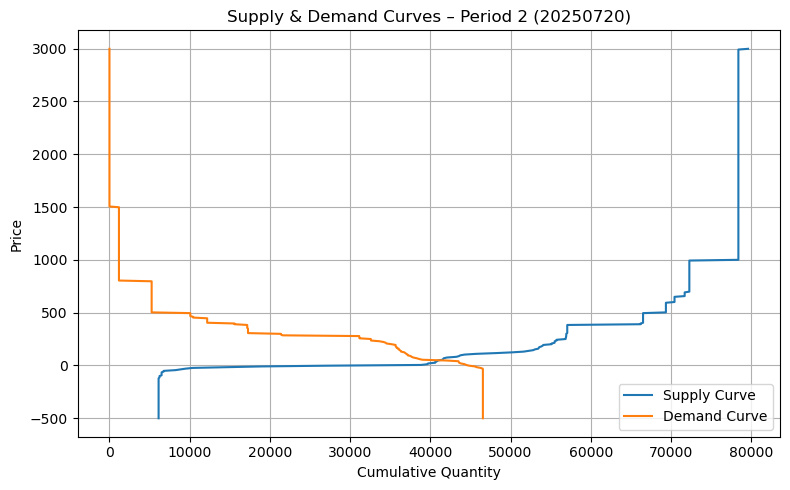

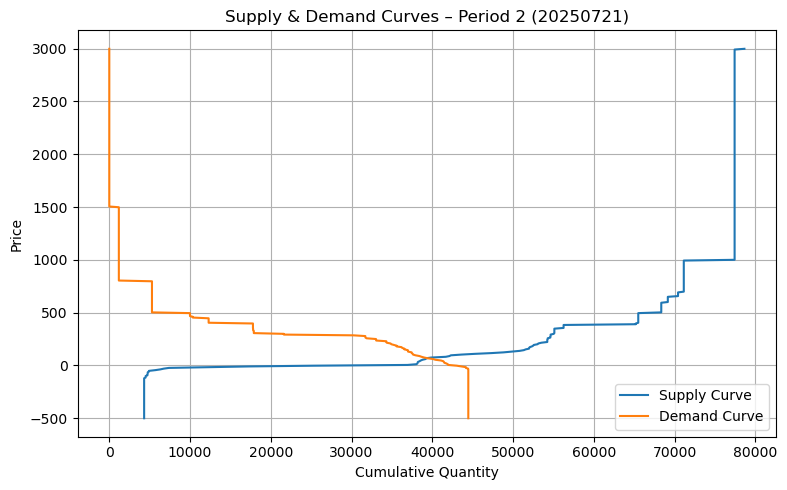

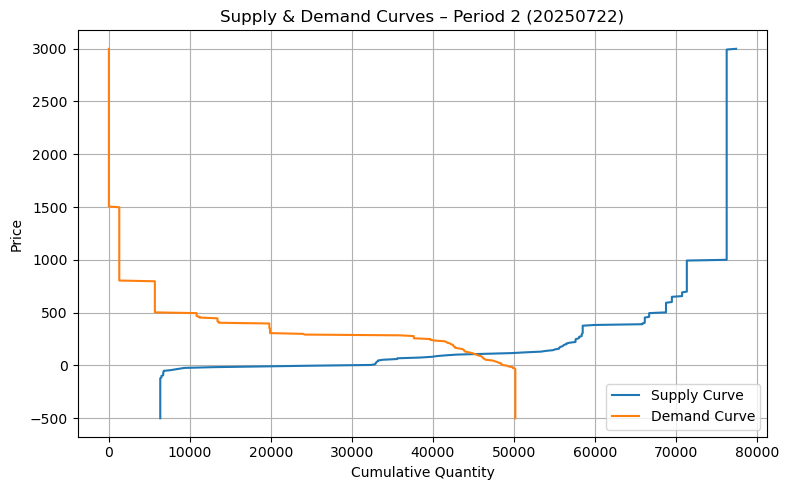

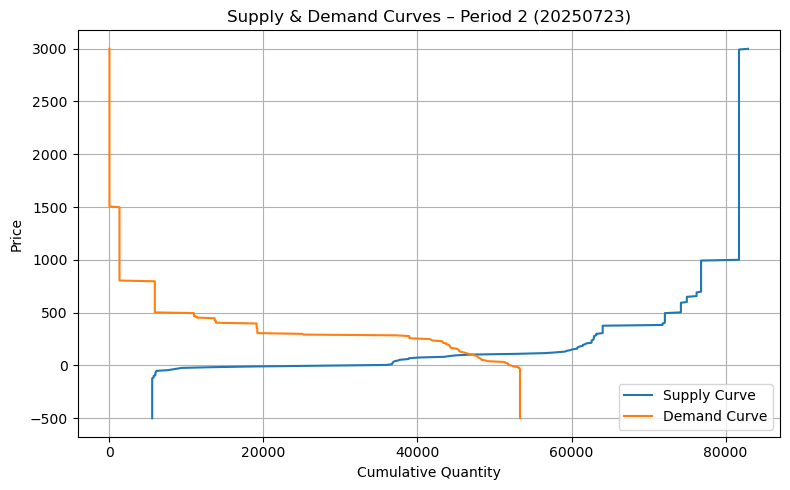

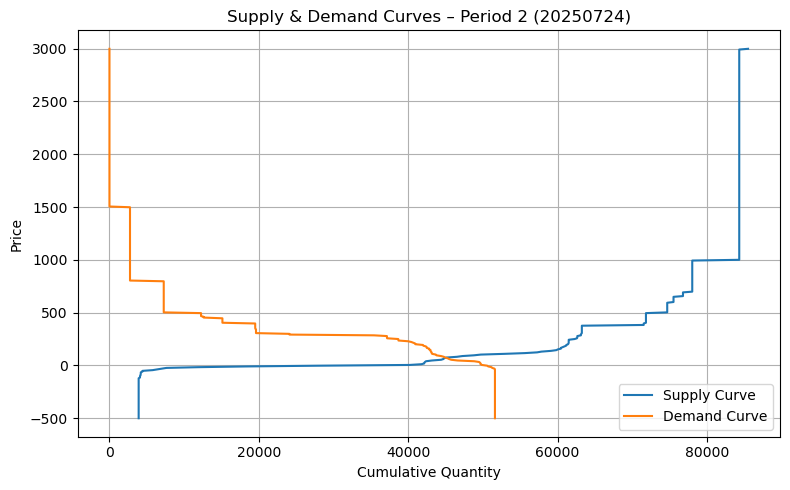

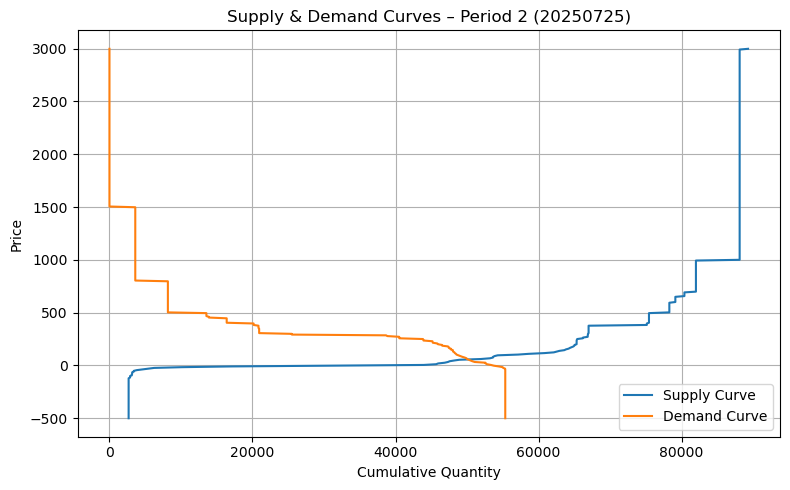

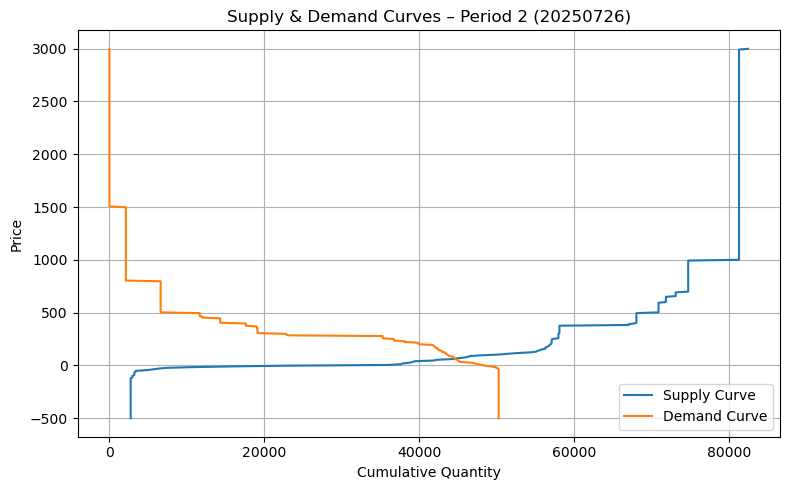

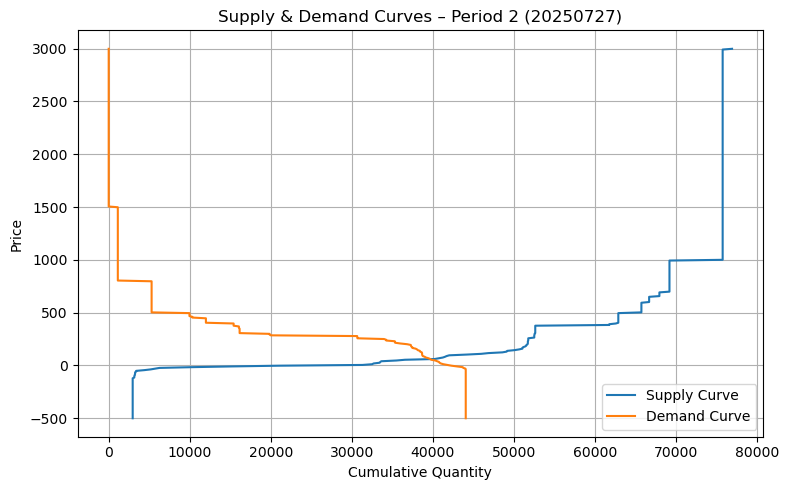

In [87]:
# 반복할 날짜와 필터 기간 설정
period = 2
days = range(20, 28)


for day in days:
    date_str = f"202507{day:02d}"
    file_in = f"filteredcurve_{date_str}.csv"
    
    # 파일이 없으면 건너뜀
    try:
        df = pd.read_csv(file_in, sep=',', encoding='utf-8-sig')
    except FileNotFoundError:
        print(f"파일 없음: {file_in}")
        continue

    # period 필터
    mask = df['Time Period'] == period
    supply = df[mask & (df['GC'] == 'V')]
    demand = df[mask & (df['GC'] == 'C')]

    # 공급 집계
    supply_agg = (
        supply.groupby('Price')['Amount']
              .sum()
              .reset_index()
              .sort_values('Price')
    )
    supply_agg['CumulQty'] = supply_agg['Amount'].cumsum()

    # 수요 집계
    demand_agg = (
        demand.groupby('Price')['Amount']
              .sum()
              .reset_index()
              .sort_values('Price')
    )
    demand_agg['CumulQty'] = demand_agg['Amount'][::-1].cumsum()[::-1]

    # 보간 함수 정의
    supply_func = interp1d(
        supply_agg['Price'], supply_agg['CumulQty'],
        kind='previous', bounds_error=False,
        fill_value=(0, supply_agg['CumulQty'].iloc[-1])
    )
    demand_func = interp1d(
        demand_agg['Price'], demand_agg['CumulQty'],
        kind='previous', bounds_error=False,
        fill_value=(demand_agg['CumulQty'].iloc[0], 0)
    )

    # 보간용 그리드
    pmin = min(supply_agg['Price'].min(), demand_agg['Price'].min())
    pmax = max(supply_agg['Price'].max(), demand_agg['Price'].max())
    price_grid = np.linspace(pmin, pmax, 500)
    supply_vals = supply_func(price_grid)
    demand_vals = demand_func(price_grid)

    # 플롯
    plt.figure(figsize=(8,5))
    plt.plot(supply_vals, price_grid, label='Supply Curve')
    plt.plot(demand_vals, price_grid, label='Demand Curve')
    plt.xlabel('Cumulative Quantity')
    plt.ylabel('Price')
    plt.title(f'Supply & Demand Curves – Period {period} ({date_str})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Residual Demand Curve

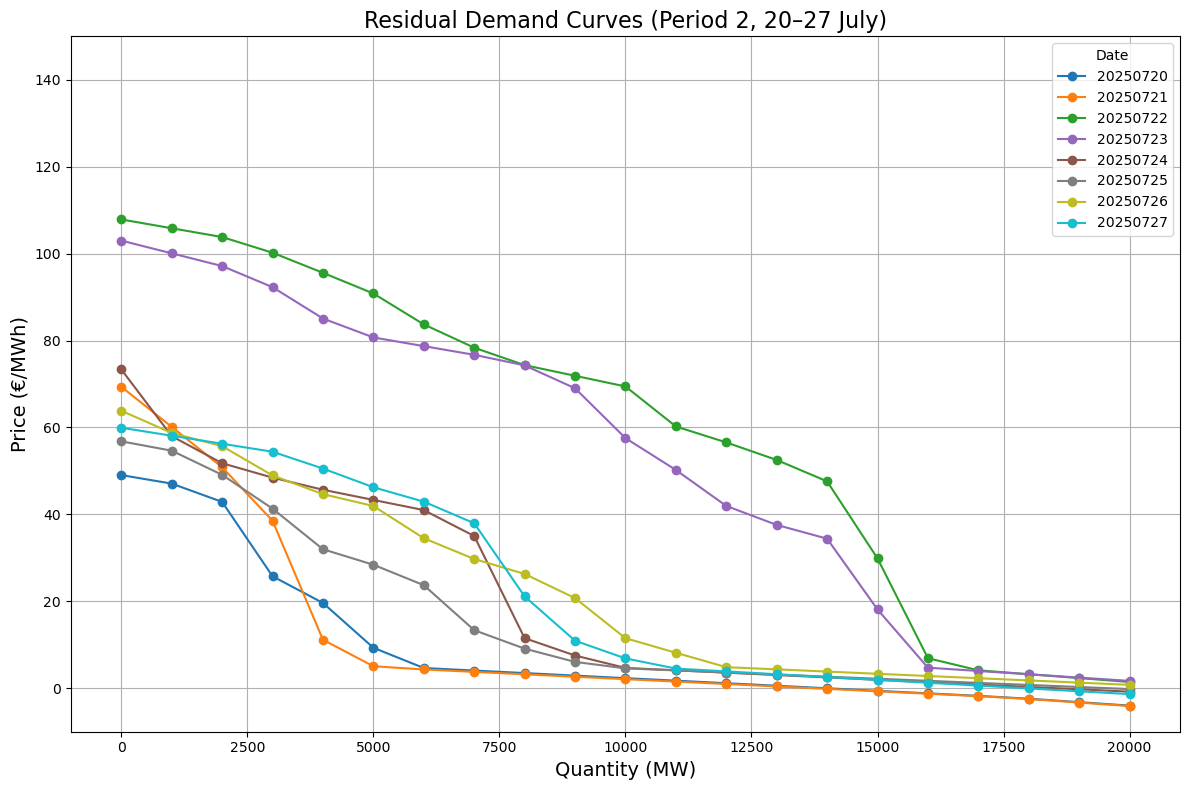

In [8]:
# --- A) 잔여수요 계산 함수 (선형보간) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0, p1 = price_grid[i],     price_grid[i+1]
            r0, r1 = resid[i],          resid[i+1]
            if r1 != r0:
                p_star = p0 - r0 * (p1 - p0) / (r1 - r0)
                rdc.append((q, p_star))
    return rdc

# --- B) 공통 설정 ---
period       = 2
days         = range(20, 28)   # 20~27일
n_rdc_points = 30

# --- C) stepwise 설정
qini            = {}
qmax            = {}
lambda_da_block = {}
B = 10  # 원하시는 블록 개수로 조정하세요

# 컬러맵
colors = plt.cm.tab10(np.linspace(0,1,len(days)))

plt.figure(figsize=(12,8))

for day, color in zip(days, colors):
    date_str = f"202507{day:02d}"
    fn       = f"filteredcurve_{date_str}.csv"
    try:
        df = pd.read_csv(fn, encoding='utf-8-sig')
    except FileNotFoundError:
        print(f"⚠ 파일 없음: {fn}")
        continue

    # Price/Amount 이미 float라 가정
    # Period 필터
    sub    = df[df['Time Period'] == period]
    supply = sub[sub['GC'] == 'V']
    demand = sub[sub['GC'] == 'C']
    if supply.empty or demand.empty:
        print(f"⚠ 데이터 부족: {date_str}")
        continue

    # 공급/수요 집계
    s_agg = supply.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
    s_agg['CumulQty'] = s_agg['Amount'].cumsum()
    d_agg = demand.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
    d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

    # 계단형 보간
    supply_func = interp1d(s_agg['Price'],    s_agg['CumulQty'],
                           kind='previous', bounds_error=False,
                           fill_value=(0, s_agg['CumulQty'].iat[-1]))
    demand_func = interp1d(d_agg['Price'],    d_agg['CumulQty'],
                           kind='previous', bounds_error=False,
                           fill_value=(d_agg['CumulQty'].iat[0], 0))

    price_grid   = np.linspace(
        min(s_agg['Price'].min(), d_agg['Price'].min()),
        max(s_agg['Price'].max(), d_agg['Price'].max()),
        500
    )
    supply_vals  = supply_func(price_grid)
    demand_vals  = demand_func(price_grid)
    # 풍력 입찰량 격자: 0, 100, 200, …, 50000
    wf_offer_grid = np.arange(0, 20001, 1000)
    rdc_pts = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offer_grid)
    q_vals, p_vals = zip(*rdc_pts)

    # ——— 여기에 stepwise 근사 파라미터 계산 추가 —————————
    qv = np.array(q_vals)
    pv = np.array(p_vals)
    t  = day  # 또는 원하는 시간 인덱스로 사용

    if qv.size > 0:
        q_breaks   = np.linspace(0, qv.max(), B+1)
        delta_qs   = q_breaks[1:] - q_breaks[:-1]
        for b in range(B):
            mid = 0.5*(q_breaks[b] + q_breaks[b+1])
            qini[(t,b)]            = float(q_breaks[b])
            qmax[(t,b)]            = float(delta_qs[b])
            lambda_da_block[(t,b)] = float(np.interp(mid, qv, pv))
    else:
        for b in range(B):
            qini[(t,b)]            = 0.0
            qmax[(t,b)]            = 0.0
            lambda_da_block[(t,b)] = 0.0
    # ——————————————————————————————————————————————

    # 이제 Residual Demand Curve만 그립니다
    plt.plot(q_vals, p_vals, 'o-', color=color, label=date_str)

# --- C) 그래프 꾸미기 ---
plt.xlabel('Quantity (MW)', fontsize=14)
plt.ylabel('Price (€/MWh)', fontsize=14)
plt.ylim(-10,150)
plt.title(f'Residual Demand Curves (Period {period}, 20–27 July)', fontsize=16)
plt.legend(title='Date', loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


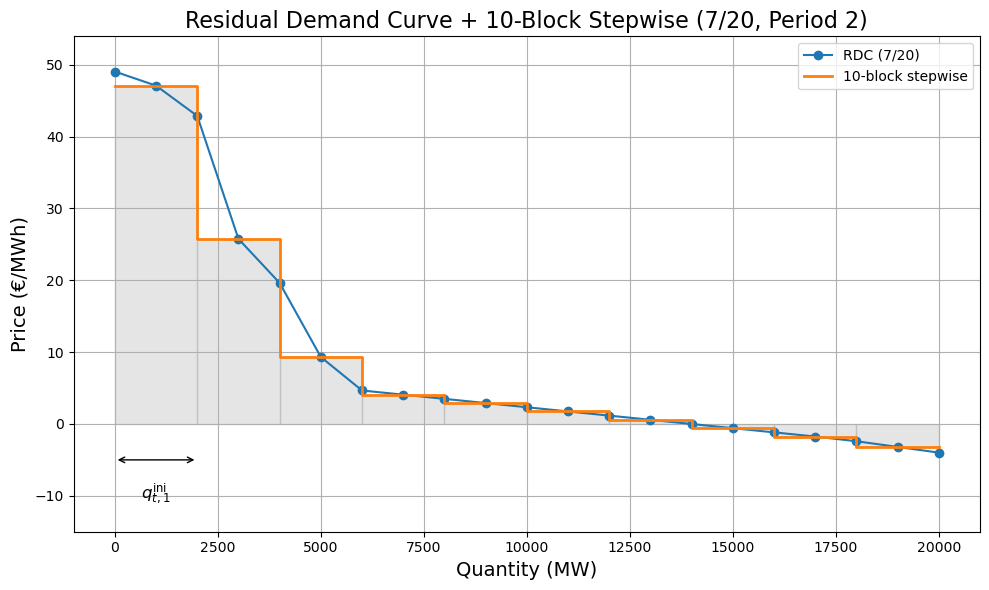

In [12]:


# --- A) 잔여수요 계산 함수 (선형보간) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0, p1 = price_grid[i],     price_grid[i+1]
            r0, r1 = resid[i],          resid[i+1]
            if r1 != r0:
                p_star = p0 - r0 * (p1 - p0) / (r1 - r0)
                rdc.append((q, p_star))
    return rdc

# --- 1) 파라미터 설정 ---
period        = 2
date_str      = "20250720"         # 7월 20일
fn            = f"filteredcurve_{date_str}.csv"
B             = 10                 # 블록 수
wf_offer_grid = np.arange(0, 20001, 1000)

# --- 2) 데이터 읽기 & 전처리 ---
df = pd.read_csv(fn, encoding='utf-8-sig')
sub    = df[df['Time Period']==period]
supply = sub[sub['GC']=='V']
demand = sub[sub['GC']=='C']
if supply.empty or demand.empty:
    raise ValueError(f"{date_str}에 period={period} 데이터가 없습니다.")

# 공급/수요 누적 집계
s_agg = supply.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
s_agg['CumulQty'] = s_agg['Amount'].cumsum()
d_agg = demand.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

# 계단형 보간 함수
supply_func = interp1d(
    s_agg['Price'], s_agg['CumulQty'],
    kind='previous', bounds_error=False,
    fill_value=(0, s_agg['CumulQty'].iat[-1])
)
demand_func = interp1d(
    d_agg['Price'], d_agg['CumulQty'],
    kind='previous', bounds_error=False,
    fill_value=(d_agg['CumulQty'].iat[0], 0)
)

# 가격 그리드
price_grid  = np.linspace(
    min(s_agg['Price'].min(), d_agg['Price'].min()),
    max(s_agg['Price'].max(), d_agg['Price'].max()),
    500
)
supply_vals = supply_func(price_grid)
demand_vals = demand_func(price_grid)

# 잔여수요 계산
rdc_pts = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offer_grid)
if not rdc_pts:
    raise RuntimeError("RDC 점이 계산되지 않았습니다.")
q_vals, p_vals = zip(*rdc_pts)
qv = np.array(q_vals)
pv = np.array(p_vals)

# --- 3) Stepwise 근사 계산 ---
q_breaks = np.linspace(0, qv.max(), B+1)      # 블록 경계
block_prices = []
for b in range(B):
    mid_q = 0.5*(q_breaks[b] + q_breaks[b+1])
    # 중간점 가격을 원래 RDC에서 선형보간
    price_b = float(np.interp(mid_q, qv, pv))
    block_prices.append(price_b)
# 마지막 구간 닫기 위해 마지막 가격 추가
block_prices.append(block_prices[-1])

# --- 4) 시각화 ---
plt.figure(figsize=(10,6))

# 4.1) 원본 RDC
plt.plot(qv, pv, 'o-', label='RDC (7/20)', linewidth=1.5)

# 4.2) 계단식 stepwise
plt.step(q_breaks, block_prices, where='post',
         label='10-block stepwise', linewidth=2)

# 4.3) 각 블록 음영
for b in range(B):
    plt.fill_between(
        [q_breaks[b], q_breaks[b+1]],
        0, block_prices[b],
        color='grey', alpha=0.2
    )

# 4.4) 첫 블록(qᶦⁿⁱ) 길이 화살표
plt.annotate(
    '',
    xy=(q_breaks[1], -5), xytext=(q_breaks[0], -5),
    arrowprops=dict(arrowstyle='<->', color='black')
)
plt.text(
    0.5*(q_breaks[0]+q_breaks[1]), -8,
    r'$q^{\mathrm{ini}}_{t,1}$',
    ha='center', va='top', fontsize=12
)

# 4.5) 축·범례·제목
plt.xlabel('Quantity (MW)', fontsize=14)
plt.ylabel('Price (€/MWh)', fontsize=14)
plt.ylim(-15, max(pv.max(), block_prices[0]) * 1.1)
plt.title('Residual Demand Curve + 10-Block Stepwise (7/20, Period 2)', fontsize=16)
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


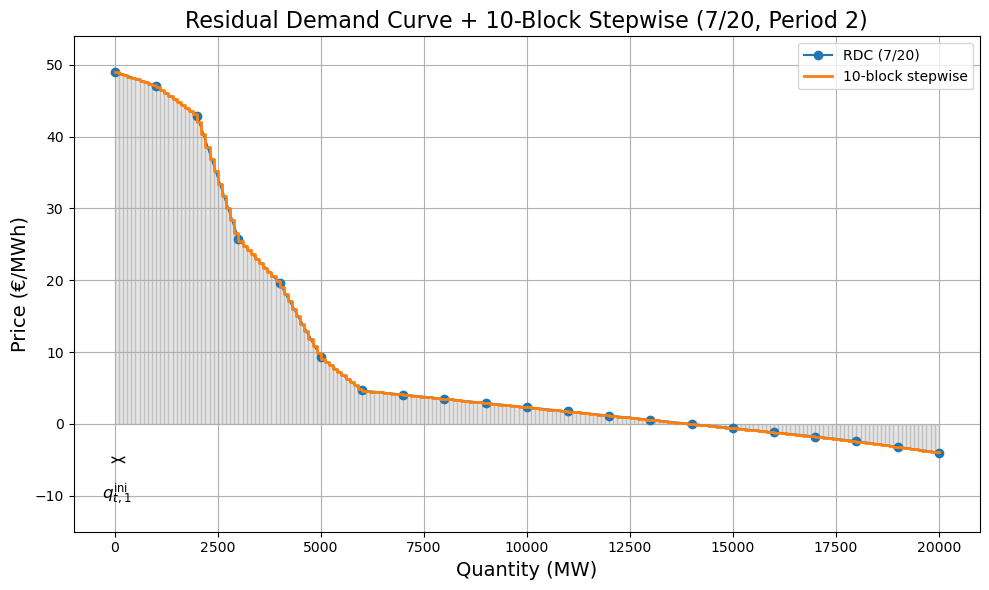

In [17]:


# --- A) 잔여수요 계산 함수 (선형보간) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0, p1 = price_grid[i],     price_grid[i+1]
            r0, r1 = resid[i],          resid[i+1]
            if r1 != r0:
                p_star = p0 - r0 * (p1 - p0) / (r1 - r0)
                rdc.append((q, p_star))
    return rdc

# --- 1) 파라미터 설정 ---
period        = 2
date_str      = "20250720"         # 7월 20일
fn            = f"filteredcurve_{date_str}.csv"
B             = 200                 # 블록 수
wf_offer_grid = np.arange(0, 20001, 1000)

# --- 2) 데이터 읽기 & 전처리 ---
df = pd.read_csv(fn, encoding='utf-8-sig')
sub    = df[df['Time Period']==period]
supply = sub[sub['GC']=='V']
demand = sub[sub['GC']=='C']
if supply.empty or demand.empty:
    raise ValueError(f"{date_str}에 period={period} 데이터가 없습니다.")

# 공급/수요 누적 집계
s_agg = supply.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
s_agg['CumulQty'] = s_agg['Amount'].cumsum()
d_agg = demand.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

# 계단형 보간 함수
supply_func = interp1d(
    s_agg['Price'], s_agg['CumulQty'],
    kind='previous', bounds_error=False,
    fill_value=(0, s_agg['CumulQty'].iat[-1])
)
demand_func = interp1d(
    d_agg['Price'], d_agg['CumulQty'],
    kind='previous', bounds_error=False,
    fill_value=(d_agg['CumulQty'].iat[0], 0)
)

# 가격 그리드
price_grid  = np.linspace(
    min(s_agg['Price'].min(), d_agg['Price'].min()),
    max(s_agg['Price'].max(), d_agg['Price'].max()),
    500
)
supply_vals = supply_func(price_grid)
demand_vals = demand_func(price_grid)

# 잔여수요 계산
rdc_pts = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offer_grid)
if not rdc_pts:
    raise RuntimeError("RDC 점이 계산되지 않았습니다.")
q_vals, p_vals = zip(*rdc_pts)
qv = np.array(q_vals)
pv = np.array(p_vals)

# --- 3) Stepwise 근사 계산 ---
q_breaks = np.linspace(0, qv.max(), B+1)      # 블록 경계
block_prices = []
for b in range(B):
    mid_q = 0.5*(q_breaks[b] + q_breaks[b+1])
    # 중간점 가격을 원래 RDC에서 선형보간
    price_b = float(np.interp(mid_q, qv, pv))
    block_prices.append(price_b)
# 마지막 구간 닫기 위해 마지막 가격 추가
block_prices.append(block_prices[-1])

# --- 4) 시각화 ---
plt.figure(figsize=(10,6))

# 4.1) 원본 RDC
plt.plot(qv, pv, 'o-', label='RDC (7/20)', linewidth=1.5)

# 4.2) 계단식 stepwise
plt.step(q_breaks, block_prices, where='post',
         label='10-block stepwise', linewidth=2)

# 4.3) 각 블록 음영
for b in range(B):
    plt.fill_between(
        [q_breaks[b], q_breaks[b+1]],
        0, block_prices[b],
        color='grey', alpha=0.2
    )

# 4.4) 첫 블록(qᶦⁿⁱ) 길이 화살표
plt.annotate(
    '',
    xy=(q_breaks[1], -5), xytext=(q_breaks[0], -5),
    arrowprops=dict(arrowstyle='<->', color='black')
)
plt.text(
    0.5*(q_breaks[0]+q_breaks[1]), -8,
    r'$q^{\mathrm{ini}}_{t,1}$',
    ha='center', va='top', fontsize=12
)

# 4.5) 축·범례·제목
plt.xlabel('Quantity (MW)', fontsize=14)
plt.ylabel('Price (€/MWh)', fontsize=14)
plt.ylim(-15, max(pv.max(), block_prices[0]) * 1.1)
plt.title('Residual Demand Curve + 10-Block Stepwise (7/20, Period 2)', fontsize=16)
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


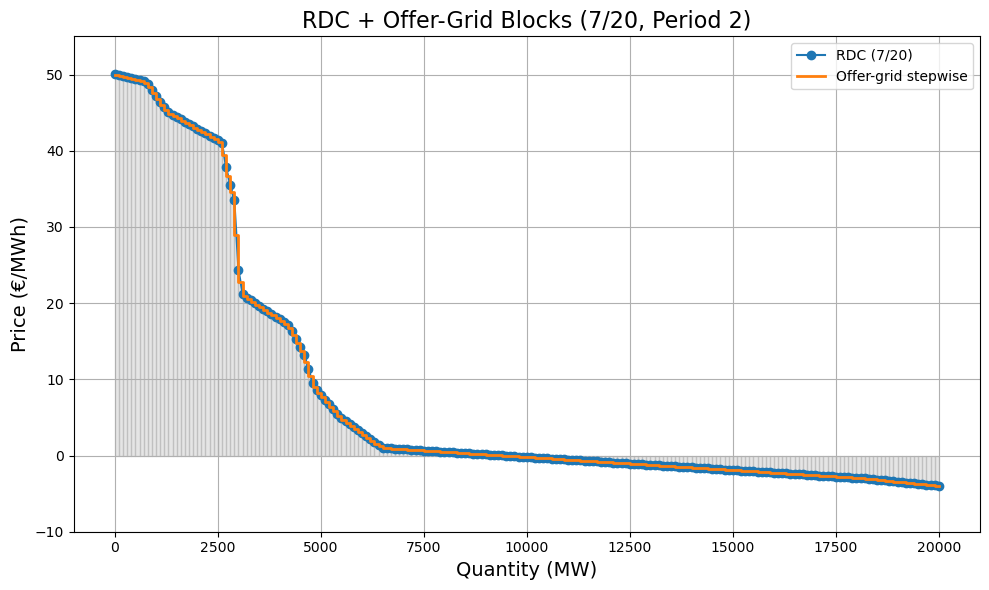

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.interpolate import interp1d

# --- A) 잔여수요 계산 함수 (선형보간) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0, p1 = price_grid[i],     price_grid[i+1]
            r0, r1 = resid[i],          resid[i+1]
            if r1 != r0:
                p_star = p0 - r0 * (p1 - p0) / (r1 - r0)
                rdc.append((q, p_star))
    return rdc

# --- 1) 파라미터 설정 ---
period        = 2
date_str      = "20250720"  
fn            = f"filteredcurve_{date_str}.csv"
df = pd.read_csv(fn, encoding='utf-8-sig')
wf_offer_grid = np.arange(0, 20001, 100)  # offer 기준 블록 경계

# --- 2) 데이터 읽기 & 전처리 ---
sub    = df[df['Time Period']==period]
supply = sub[sub['GC']=='V']
demand = sub[sub['GC']=='C']
if supply.empty or demand.empty:
    raise ValueError("데이터 부족")

# 공급/수요 누적곡선 만들기
s_agg = supply.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
s_agg['CumulQty'] = s_agg['Amount'].cumsum()
d_agg = demand.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

supply_func = interp1d(s_agg['Price'], s_agg['CumulQty'],
                       kind='previous', fill_value=(0, s_agg['CumulQty'].iat[-1]), bounds_error=False)
demand_func = interp1d(d_agg['Price'], d_agg['CumulQty'],
                       kind='previous', fill_value=(d_agg['CumulQty'].iat[0], 0), bounds_error=False)

price_grid  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
supply_vals = supply_func(price_grid)
demand_vals = demand_func(price_grid)

# RDC 점 계산
rdc_pts = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offer_grid)
qv, pv = zip(*rdc_pts)
qv = np.array(qv); pv = np.array(pv)

# --- 3) offer 그리드 기반 stepwise 계산 ---
# 각 offer 구간 중앙에서 가격 보간
offer_mids   = (wf_offer_grid[:-1] + wf_offer_grid[1:]) / 2
block_prices = np.interp(offer_mids, qv, pv)
# 마지막 구간 닫기
block_prices = np.append(block_prices, block_prices[-1])

# --- 4) 시각화 ---
plt.figure(figsize=(10,6))

# 원본 RDC
plt.plot(qv, pv, 'o-', label='RDC (7/20)', linewidth=1.5)

# offer-grid 기반 계단식 근사
plt.step(wf_offer_grid, block_prices, where='post',
         label='Offer-grid stepwise', linewidth=2)

# 각 offer 블록 음영
for i in range(len(wf_offer_grid)-1):
    plt.fill_between(
        [wf_offer_grid[i], wf_offer_grid[i+1]],
        0, block_prices[i],
        color='grey', alpha=0.2
    )

# 축·제목·범례
plt.xlabel('Quantity (MW)', fontsize=14)
plt.ylabel('Price (€/MWh)', fontsize=14)
plt.title('RDC + Offer-Grid Blocks (7/20, Period 2)', fontsize=16)
plt.ylim(-10, max(pv.max(), block_prices.max())*1.1)
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


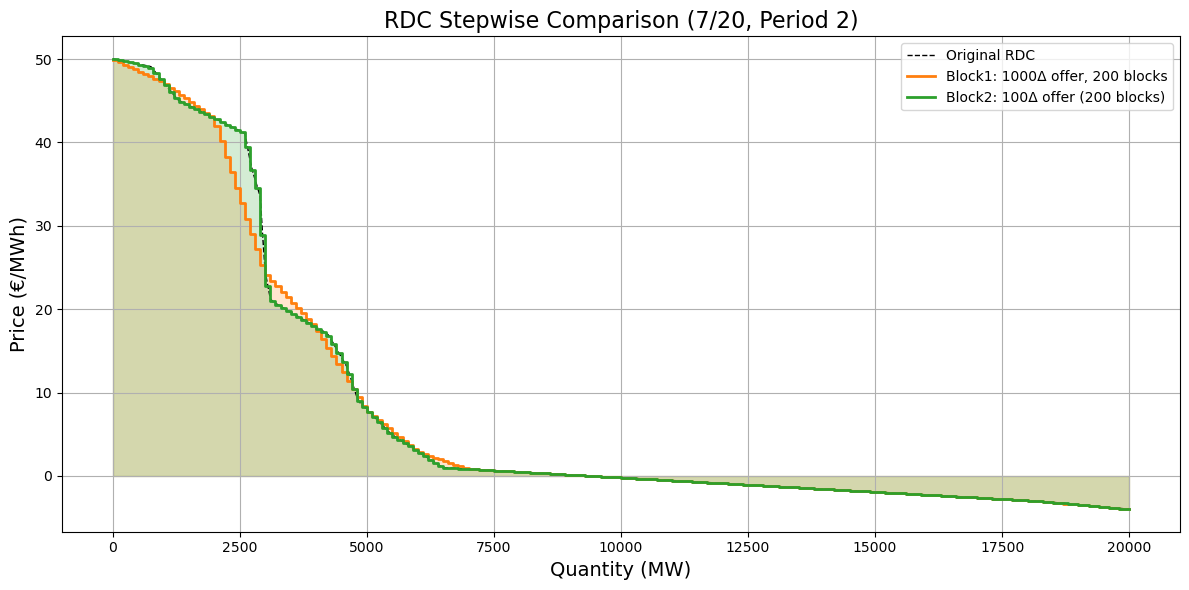

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- A) 잔여수요 계산 함수 (선형보간) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0, p1 = price_grid[i], price_grid[i+1]
            r0, r1 = resid[i], resid[i+1]
            if r1 != r0:
                p_star = p0 - r0 * (p1 - p0) / (r1 - r0)
                rdc.append((q, p_star))
    return rdc

# --- 1) 파라미터 설정 ---
period     = 2

date_str      = "20250720"  
fn            = f"filteredcurve_{date_str}.csv"
df = pd.read_csv(fn, encoding='utf-8-sig')
# (1) grid1: wf offers 0,1000,...20000
grid1 = np.arange(0, 20001, 1000)
# (2) grid2: wf offers 0,100,200,...20000
grid2 = np.arange(0, 20001, 100)

# 균등분할 블록 개수 (block1 uses grid1 rdc)
B_blocks = 200

# --- 2) 데이터 읽기 & 누적곡선 생성 ---
sub    = df[df['Time Period'] == period]
supply = sub[sub['GC'] == 'V']
demand = sub[sub['GC'] == 'C']

s_agg = supply.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
s_agg['CumulQty'] = s_agg['Amount'].cumsum()
d_agg = demand.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

supply_fn = interp1d(s_agg['Price'], s_agg['CumulQty'], kind='previous',
                     fill_value=(0, s_agg['CumulQty'].iat[-1]), bounds_error=False)
demand_fn = interp1d(d_agg['Price'], d_agg['CumulQty'], kind='previous',
                     fill_value=(d_agg['CumulQty'].iat[0], 0), bounds_error=False)

price_grid  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
supply_vals = supply_fn(price_grid)
demand_vals = demand_fn(price_grid)

# --- 3) RDC 계산 on both grids ---
rdc1 = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, grid1)
rdc2 = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, grid2)

q1, p1 = map(np.array, zip(*rdc1))
q2, p2 = map(np.array, zip(*rdc2))

# --- 4) stepwise 근사 계산 ---
# 4.1 블록1: 균등분할 B_blocks based on q1.max()
q_breaks1 = np.linspace(0, q1.max(), B_blocks + 1)
prices1   = [float(np.interp((q_breaks1[b] + q_breaks1[b+1]) / 2, q1, p1))
             for b in range(B_blocks)]
prices1.append(prices1[-1])

# 4.2 블록2: grid2 based
mids2     = (grid2[:-1] + grid2[1:]) / 2
prices2   = list(np.interp(mids2, q2, p2)) + [np.interp(mids2[-1], q2, p2)]

# --- 5) 시각화 ---
plt.figure(figsize=(12,6))

# 원본 RDC (for reference, using dense grid)
dense_offers = np.arange(0, 20001, 50)
dense_rdc    = compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, dense_offers)
qd, pd      = map(np.array, zip(*dense_rdc))
plt.plot(qd, pd, 'k--', linewidth=1, label='Original RDC')

# 첫 번째: grid1=1000 & B_blocks=200
plt.step(q_breaks1, prices1, where='post', color='C1', linewidth=2,
         label='Block1: 1000Δ offer, 200 blocks')
plt.fill_between(q_breaks1, 0, prices1, step='post', color='C1', alpha=0.2)

# 두 번째: grid2=100Δ offer, 200 blocks
plt.step(grid2, prices2, where='post', color='C2', linewidth=2,
         label='Block2: 100Δ offer (200 blocks)')
plt.fill_between(grid2, 0, prices2, step='post', color='C2', alpha=0.2)

# 꾸미기
plt.xlabel('Quantity (MW)', fontsize=14)
plt.ylabel('Price (€/MWh)', fontsize=14)
plt.title('RDC Stepwise Comparison (7/20, Period 2)', fontsize=16)
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


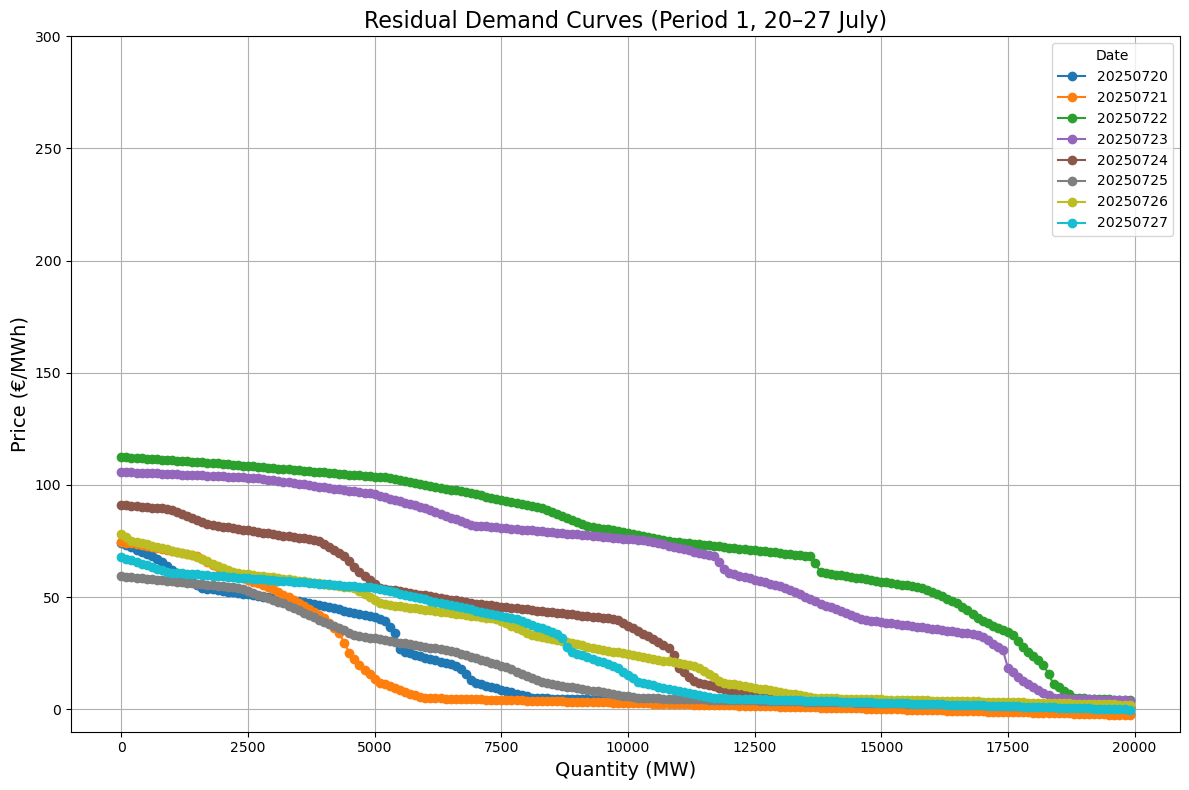

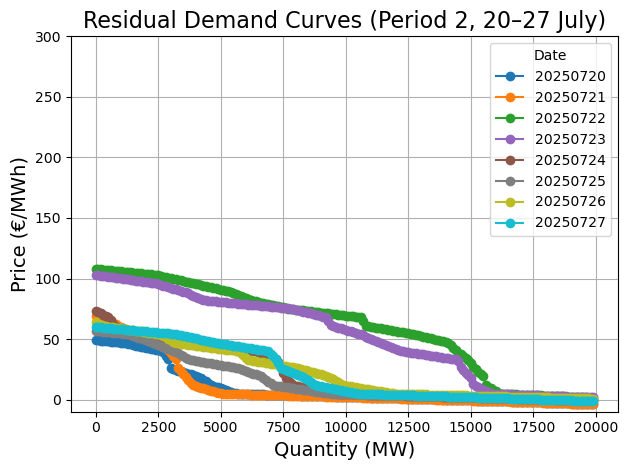

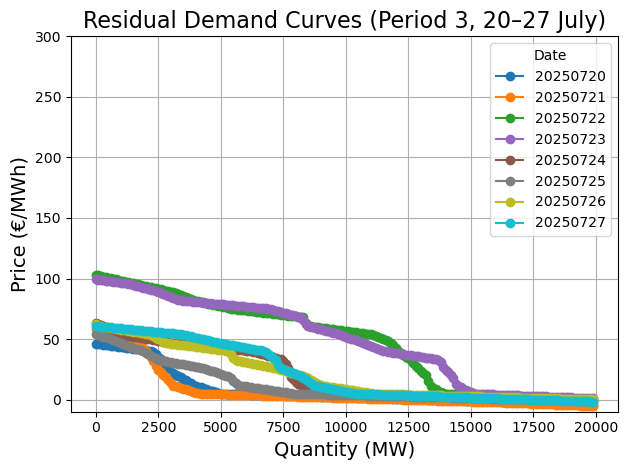

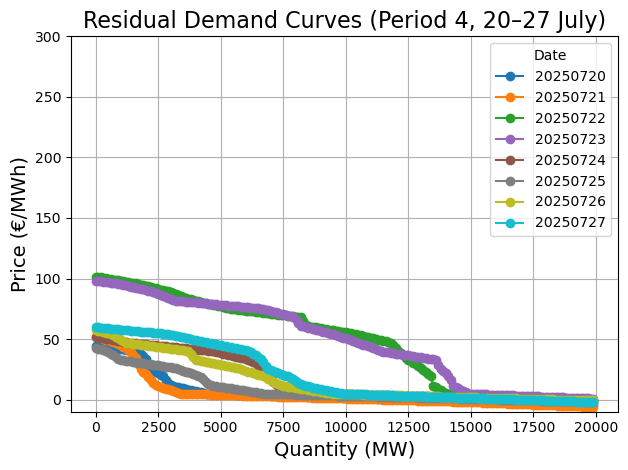

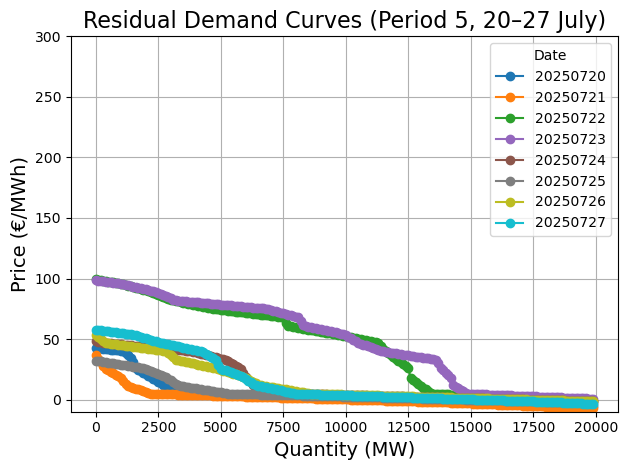

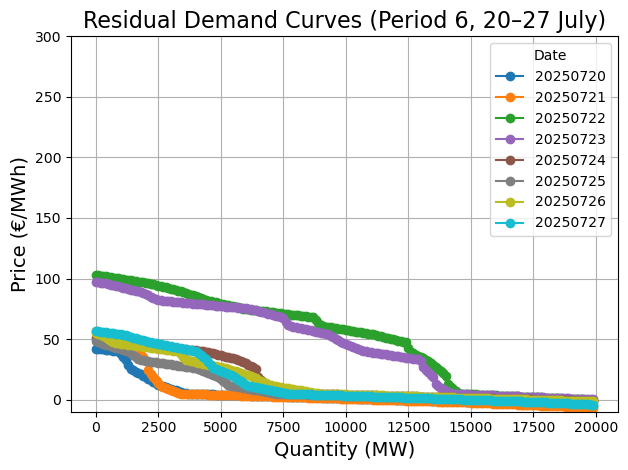

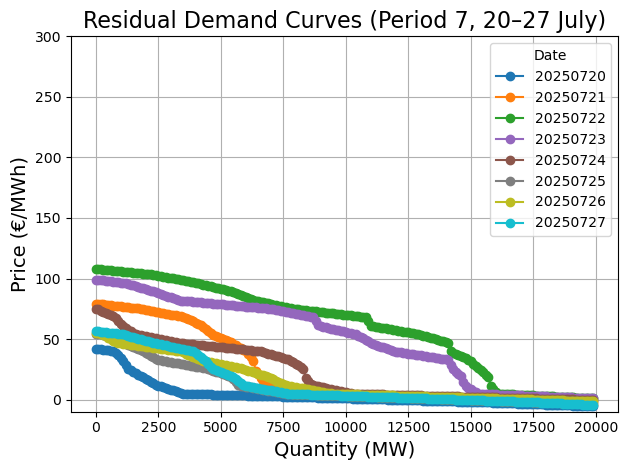

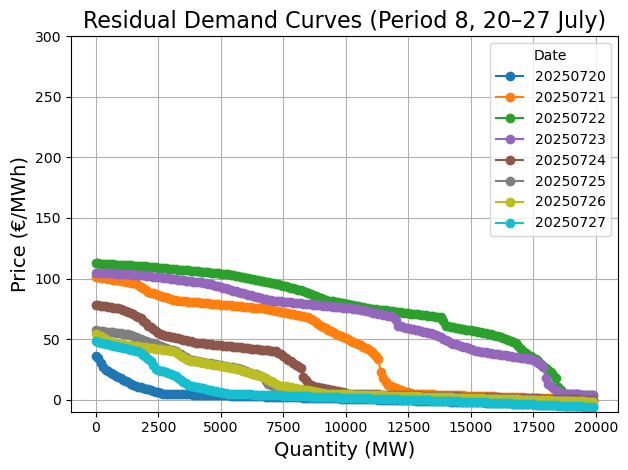

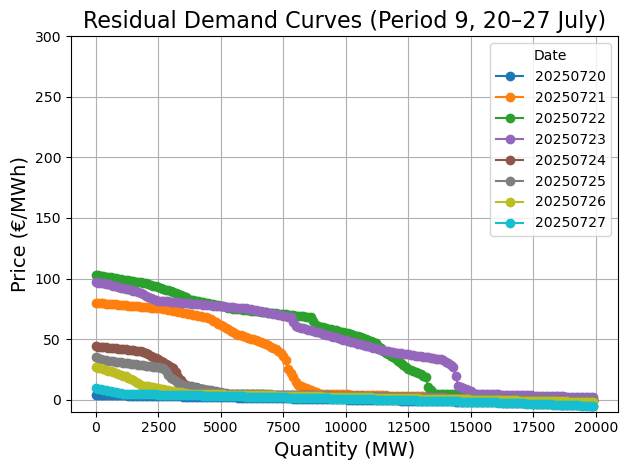

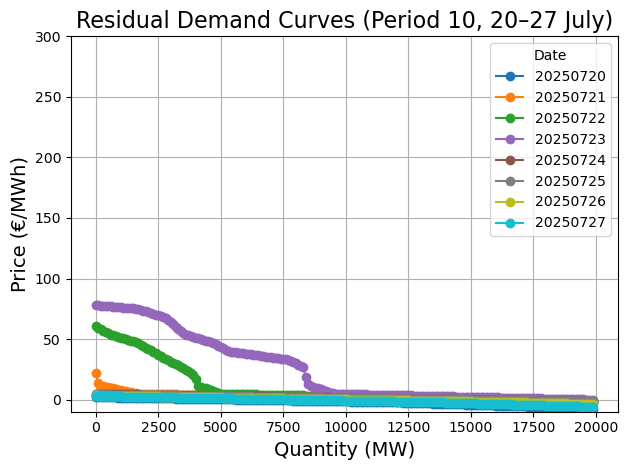

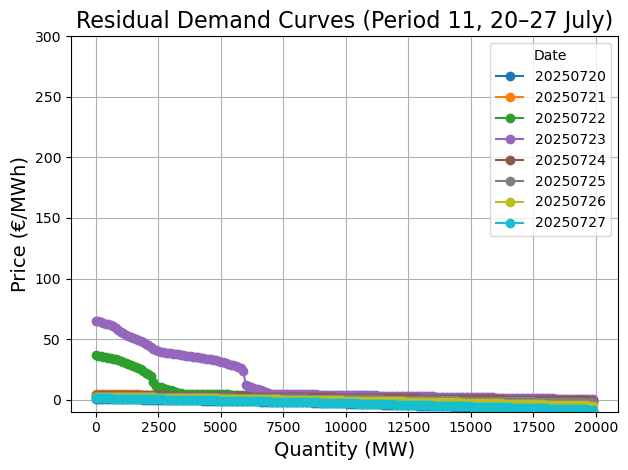

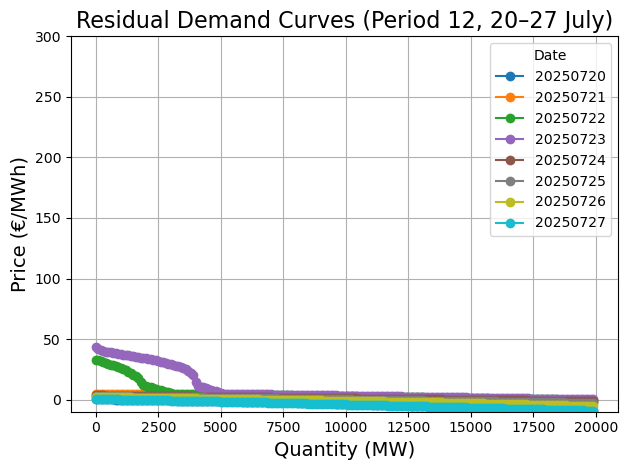

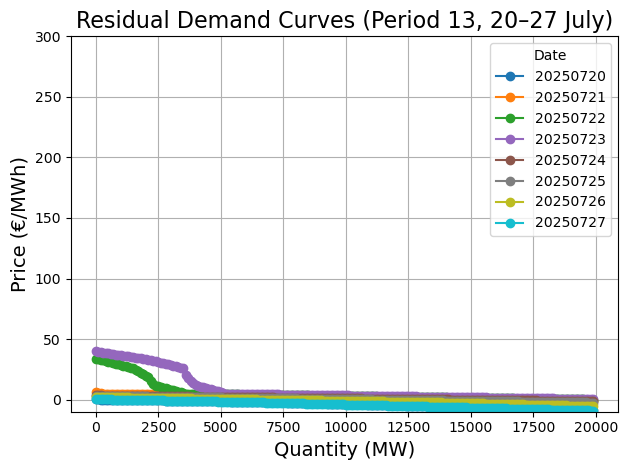

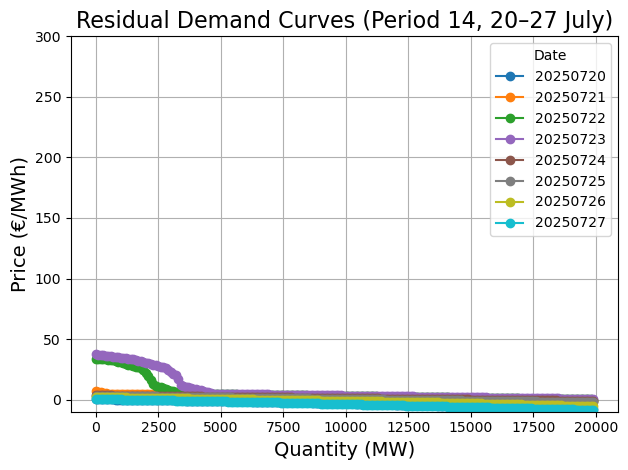

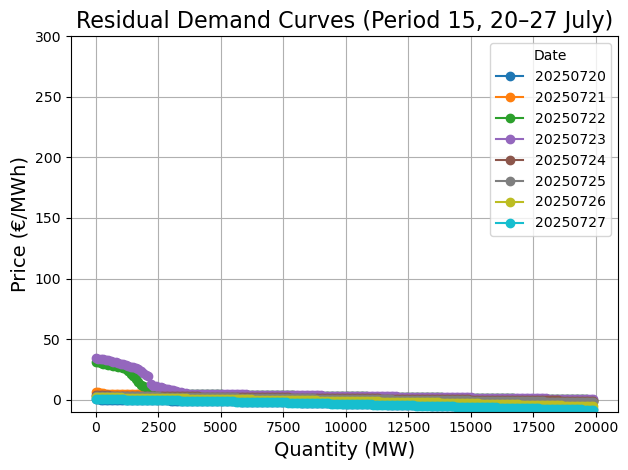

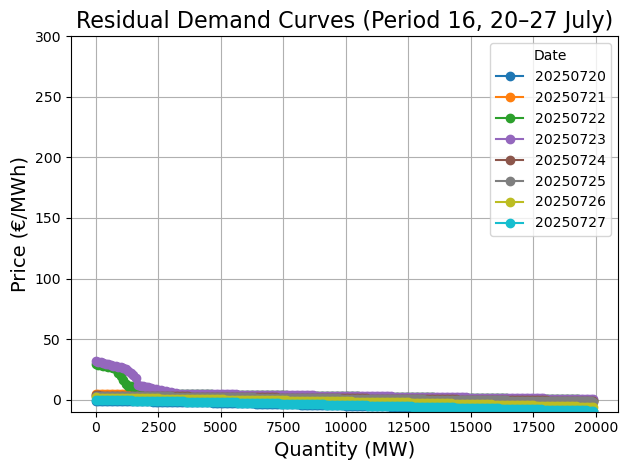

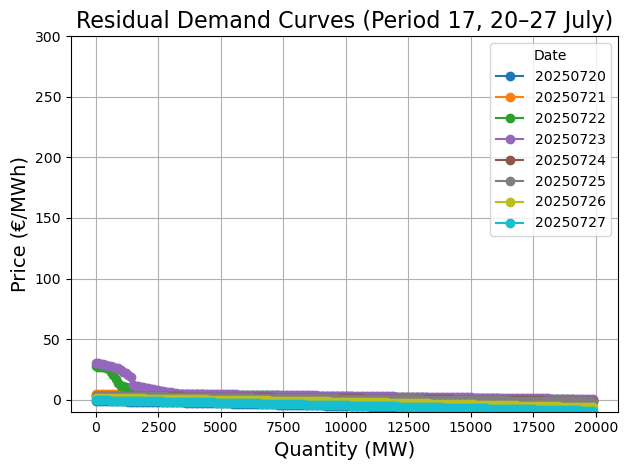

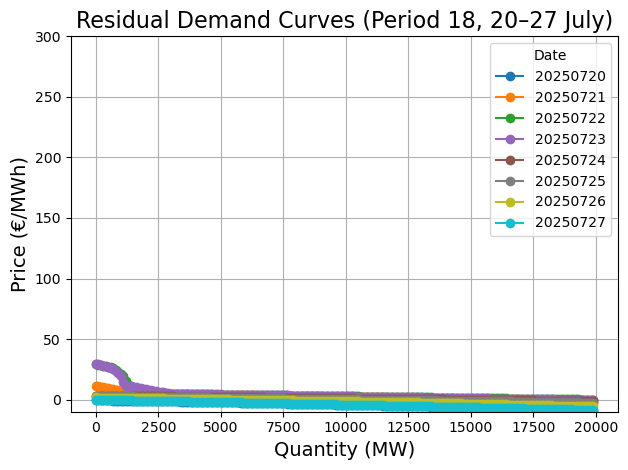

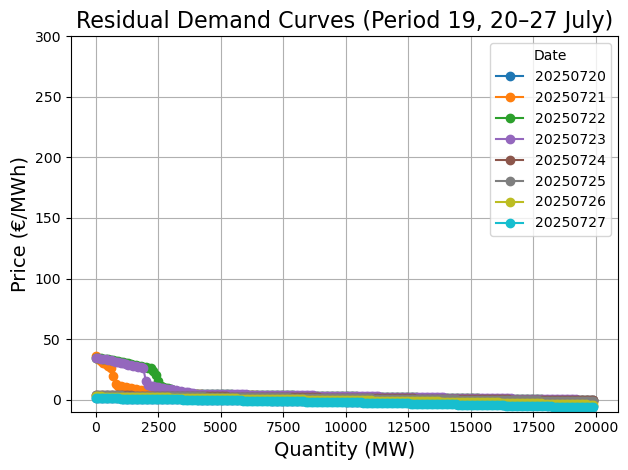

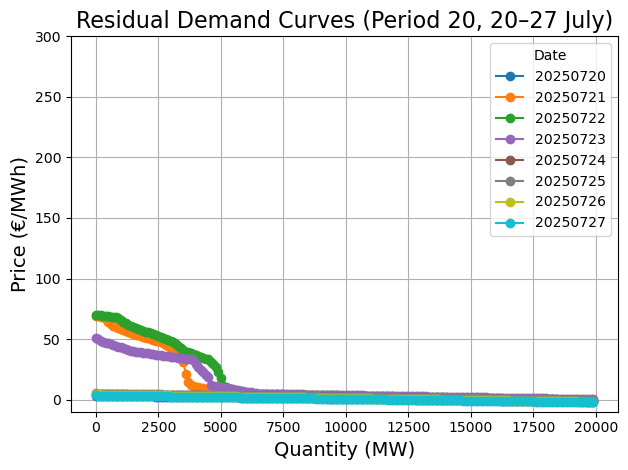

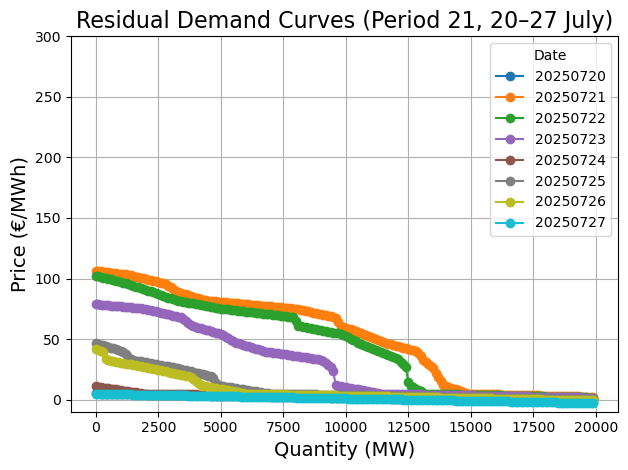

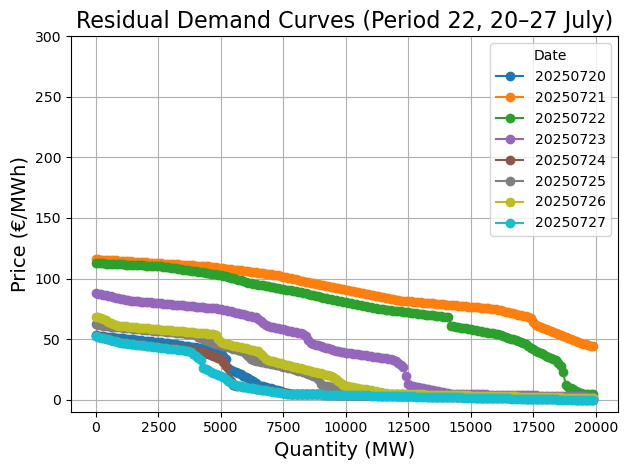

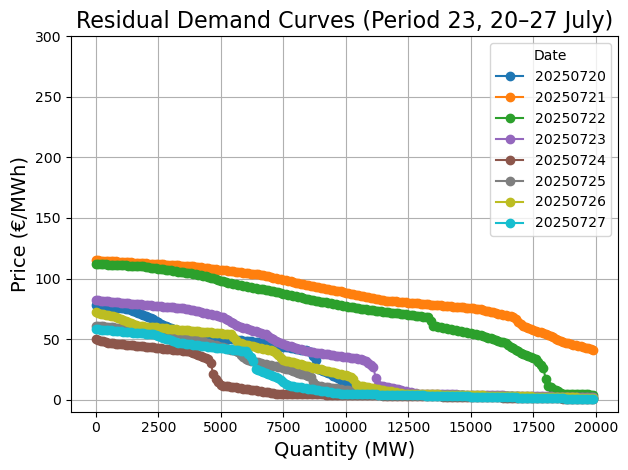

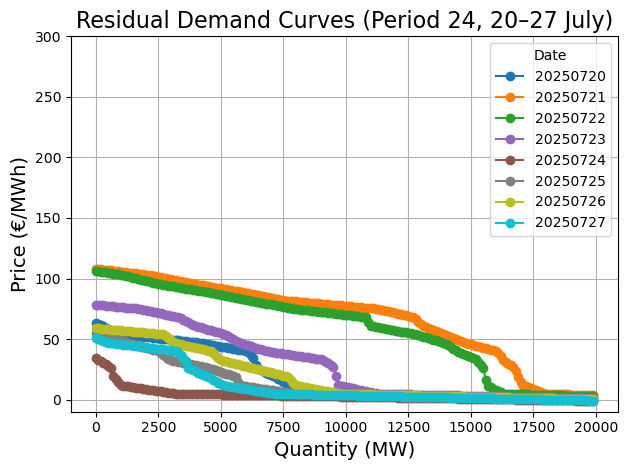

In [3]:
# --- A) 잔여수요 계산 함수 (선형보간) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0, p1 = price_grid[i],     price_grid[i+1]
            r0, r1 = resid[i],          resid[i+1]
            if r1 != r0:
                p_star = p0 - r0 * (p1 - p0) / (r1 - r0)
                rdc.append((q, p_star))
    return rdc

# --- B) 공통 설정 ---
period       = 2
days         = range(20, 28)   # 20~27일
n_rdc_points = 30

# 컬러맵
colors = plt.cm.tab10(np.linspace(0,1,len(days)))

plt.figure(figsize=(12,8))
for period in range(1, 25): 
    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"
        try:
            df = pd.read_csv(fn, encoding='utf-8-sig')
        except FileNotFoundError:
            print(f"⚠ 파일 없음: {fn}")
            continue

        # Price/Amount 이미 float라 가정
        # Period 필터
        sub    = df[df['Time Period'] == period]
        supply = sub[sub['GC'] == 'V']
        demand = sub[sub['GC'] == 'C']
        if supply.empty or demand.empty:
            print(f"⚠ 데이터 부족: {date_str}")
            continue

        # 공급/수요 집계
        s_agg = supply.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        s_agg['CumulQty'] = s_agg['Amount'].cumsum()
        d_agg = demand.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 계단형 보간
        supply_func = interp1d(s_agg['Price'],    s_agg['CumulQty'],
                            kind='previous', bounds_error=False,
                            fill_value=(0, s_agg['CumulQty'].iat[-1]))
        demand_func = interp1d(d_agg['Price'],    d_agg['CumulQty'],
                            kind='previous', bounds_error=False,
                            fill_value=(d_agg['CumulQty'].iat[0], 0))

        price_grid   = np.linspace(
            min(s_agg['Price'].min(), d_agg['Price'].min()),
            max(s_agg['Price'].max(), d_agg['Price'].max()),
            500
        )
        supply_vals  = supply_func(price_grid)
        demand_vals  = demand_func(price_grid)
        # 풍력 입찰량 격자: 0, 100, 200, …, 50000
        wf_offer_grid = np.arange(0, 20000, 100)

        # Residual Demand 계산
        rdc_pts = compute_rdc_by_sign_change(
            price_grid, demand_vals, supply_vals, wf_offer_grid
        )
        # None/NaN 제거
        rdc_pts = [(q,p) for q,p in rdc_pts if not np.isnan(p)]
        q_vals, p_vals = zip(*rdc_pts)

        # RDC 플롯
        plt.plot(q_vals, p_vals, 'o-', color=color, label=date_str)

    # --- C) 그래프 꾸미기 ---
    plt.xlabel('Quantity (MW)', fontsize=14)
    plt.ylabel('Price (€/MWh)', fontsize=14)
    plt.ylim(-10,300)
    plt.title(f'Residual Demand Curves (Period {period}, 20–27 July)', fontsize=16)
    plt.legend(title='Date', loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


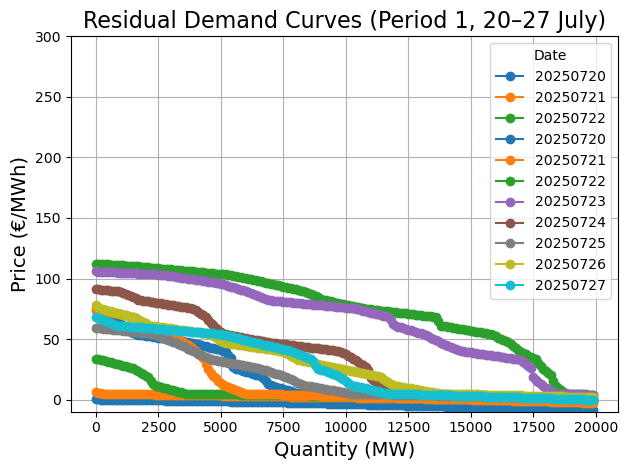

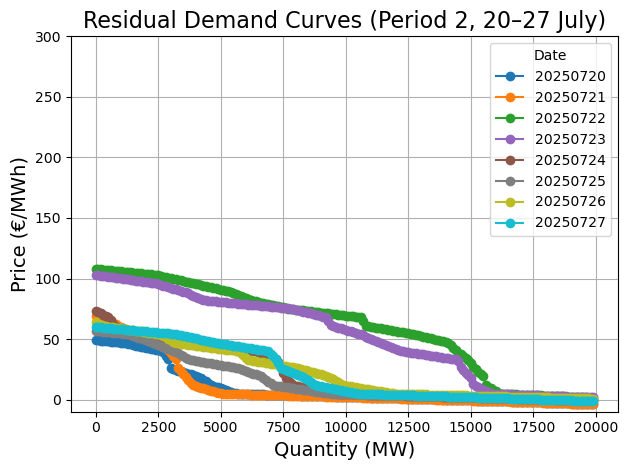

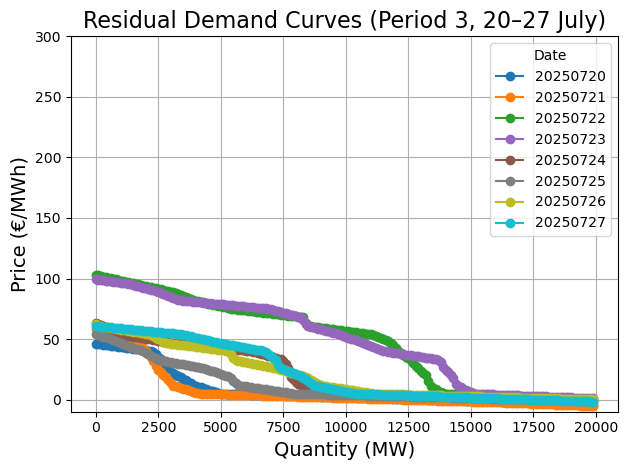

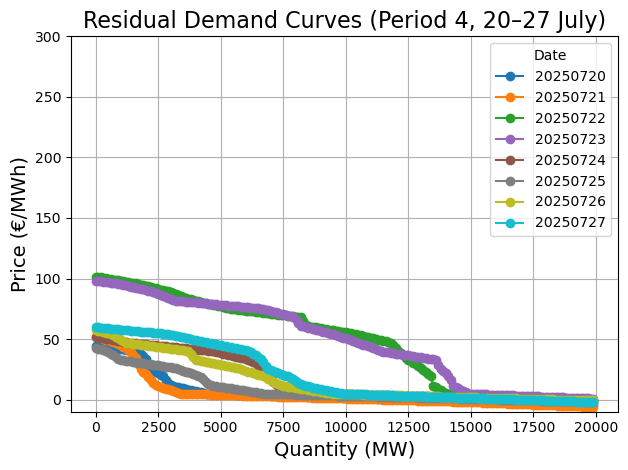

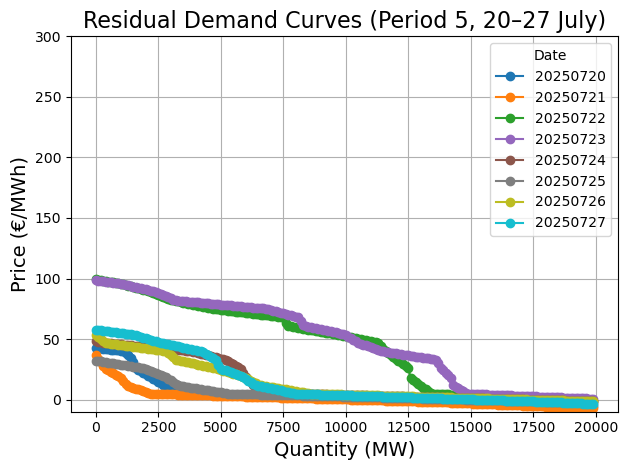

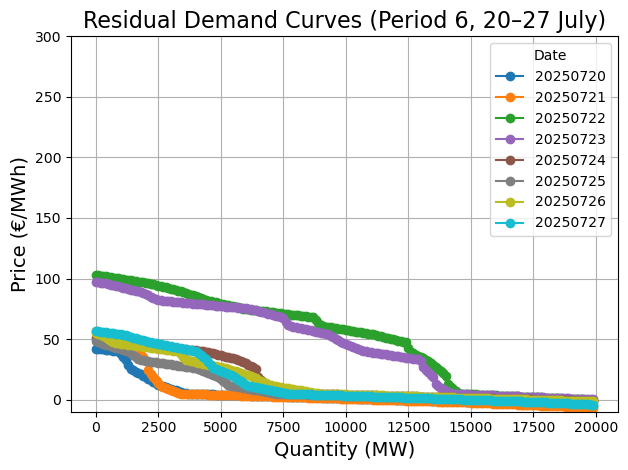

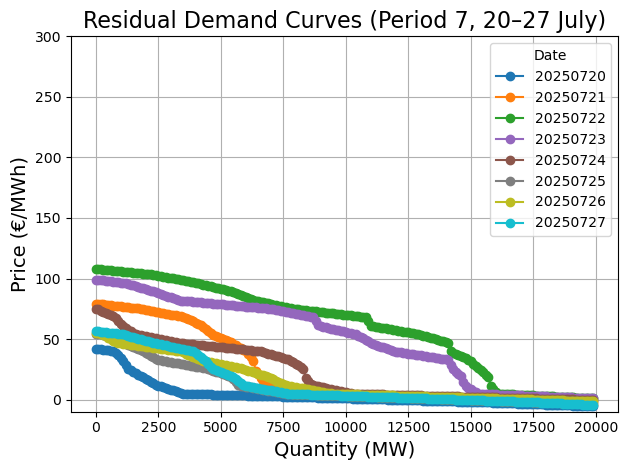

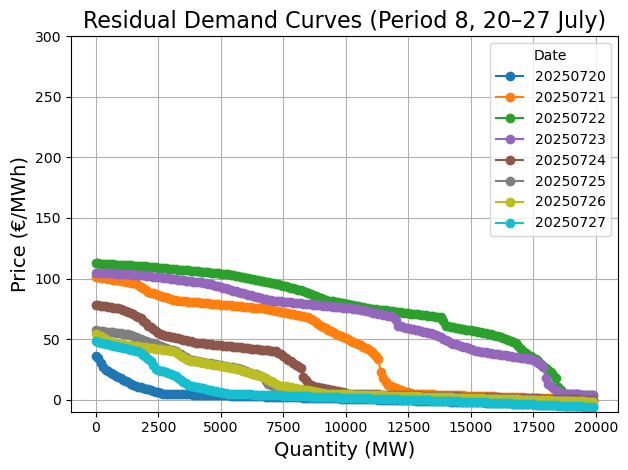

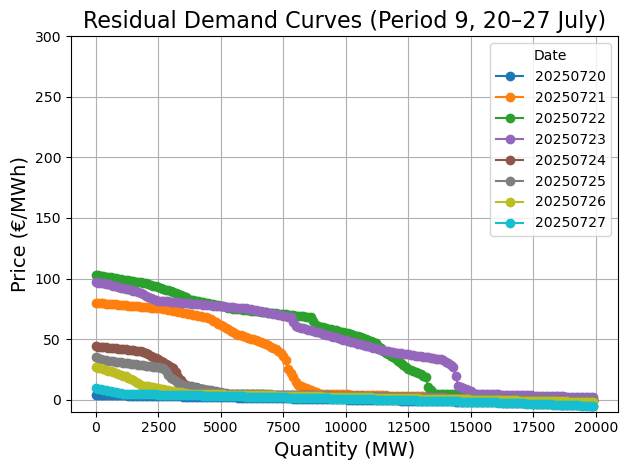

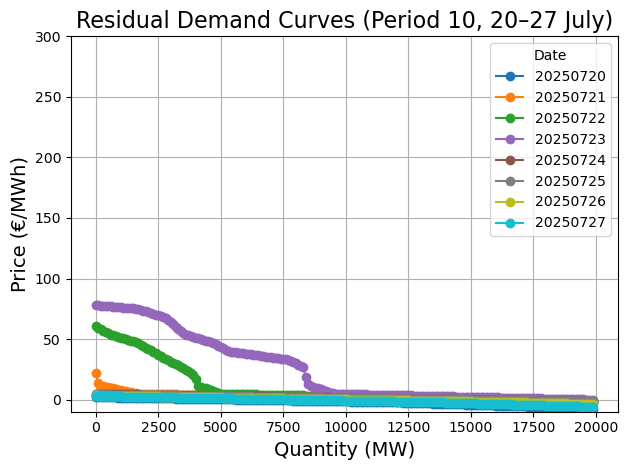

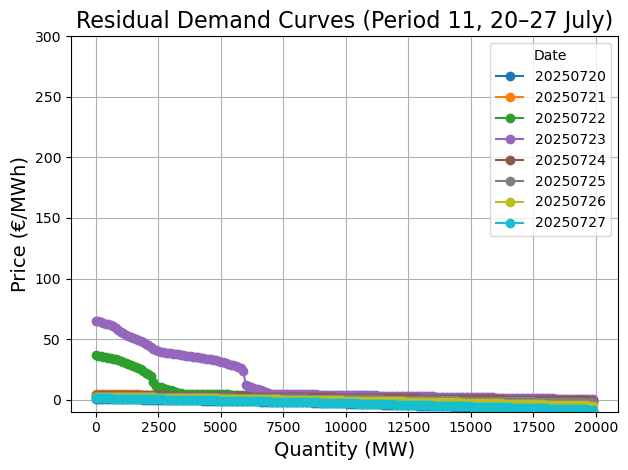

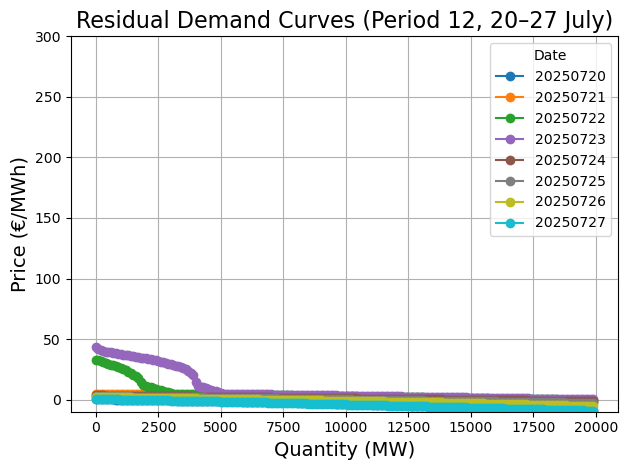

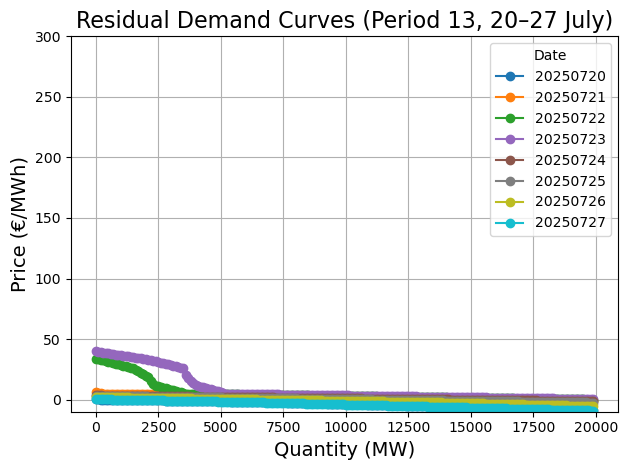

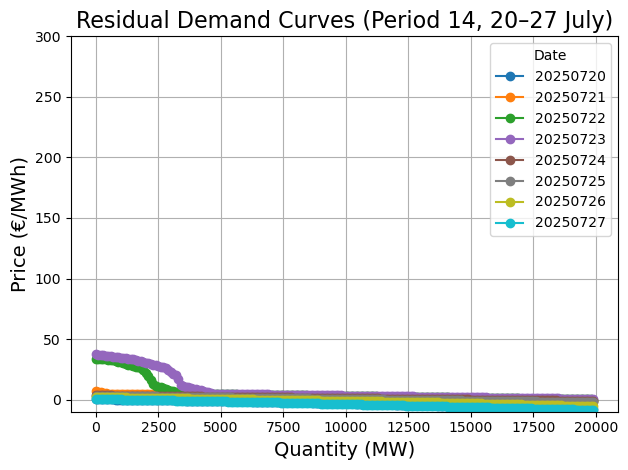

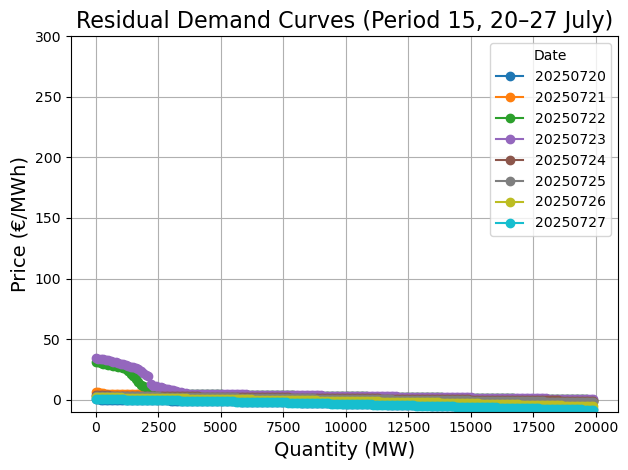

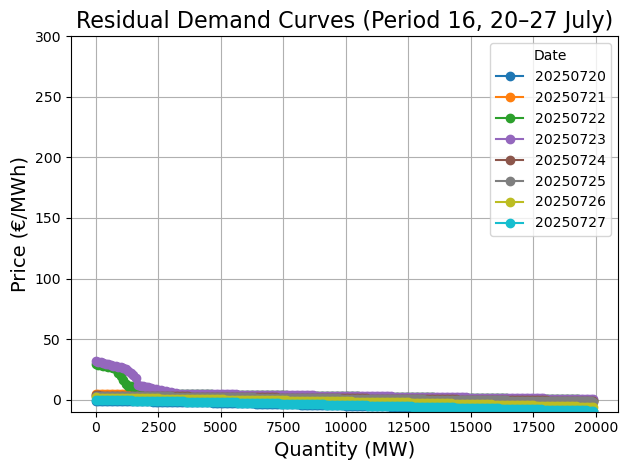

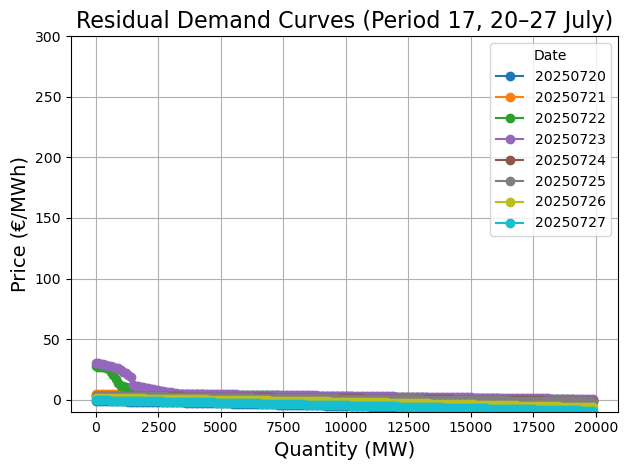

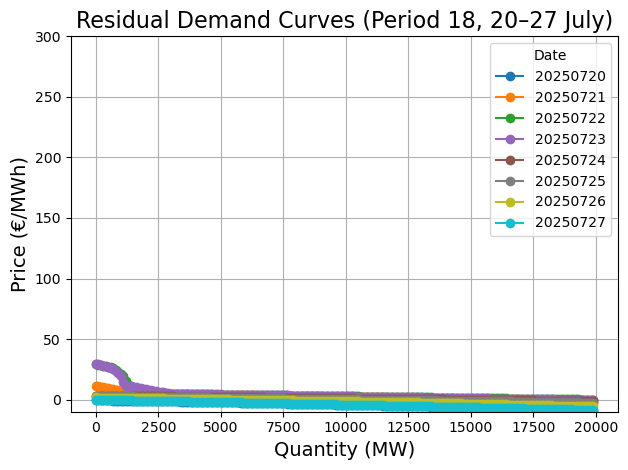

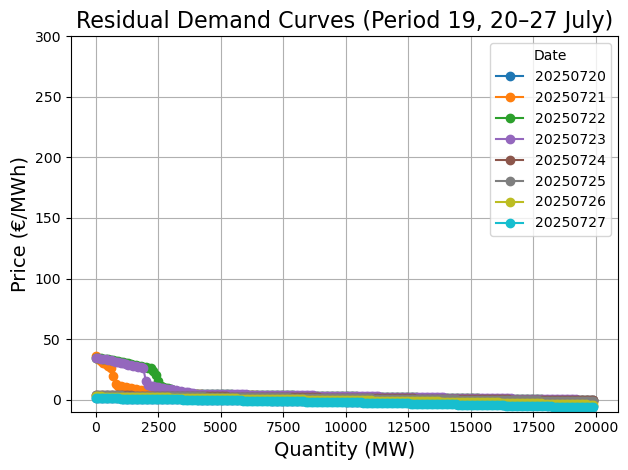

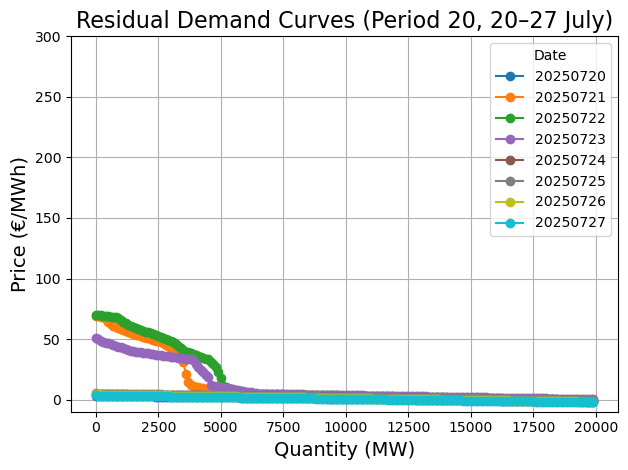

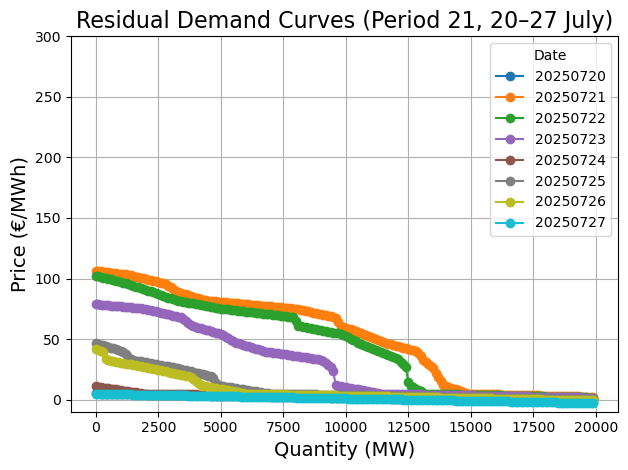

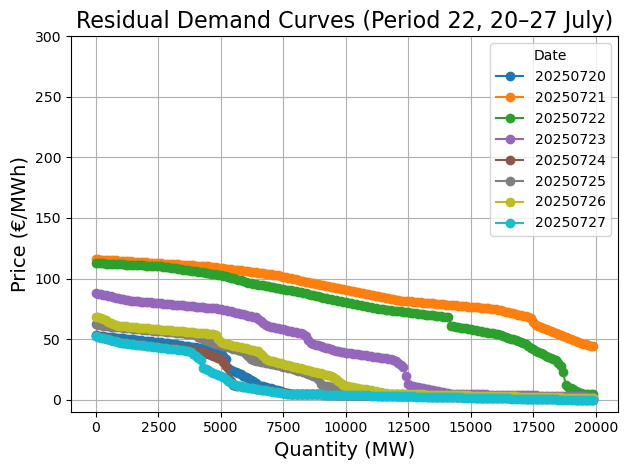

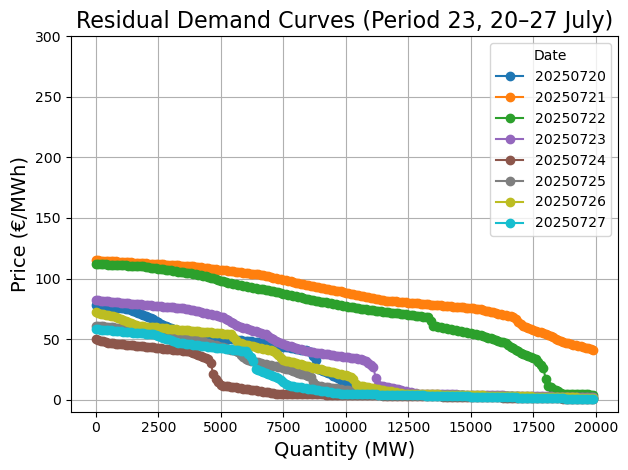

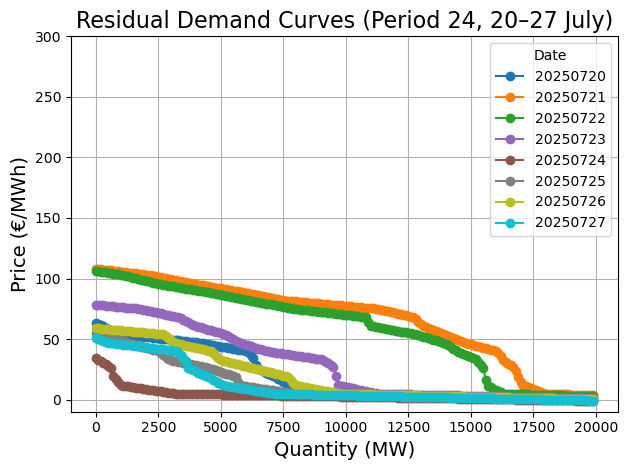

In [ ]:
# --- A) 잔여수요 계산 함수 (선형보간) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0, p1 = price_grid[i],     price_grid[i+1]
            r0, r1 = resid[i],          resid[i+1]
            if r1 != r0:
                p_star = p0 - r0 * (p1 - p0) / (r1 - r0)
                rdc.append((q, p_star))
    return rdc

# --- B) 공통 설정 ---
# period       = 2
days         = range(20, 28)   # 20~27일
n_rdc_points = 30

# 컬러맵

colors = plt.cm.tab10(np.linspace(0,1,len(days)))

for period in range(1, 25): 
    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"
        try:
            df = pd.read_csv(fn, encoding='utf-8-sig')
        except FileNotFoundError:
            print(f"⚠ 파일 없음: {fn}")
            continue

        # Price/Amount 이미 float라 가정
        # Period 필터
        sub    = df[df['Time Period'] == period]
        supply = sub[sub['GC'] == 'V']
        demand = sub[sub['GC'] == 'C']
        if supply.empty or demand.empty:
            print(f"⚠ 데이터 부족: {date_str}")
            continue

        # 공급/수요 집계
        s_agg = supply.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        s_agg['CumulQty'] = s_agg['Amount'].cumsum()
        d_agg = demand.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 계단형 보간
        supply_func = interp1d(s_agg['Price'],    s_agg['CumulQty'],
                            kind='previous', bounds_error=False,
                            fill_value=(0, s_agg['CumulQty'].iat[-1]))
        demand_func = interp1d(d_agg['Price'],    d_agg['CumulQty'],
                            kind='previous', bounds_error=False,
                            fill_value=(d_agg['CumulQty'].iat[0], 0))

        price_grid   = np.linspace(
            min(s_agg['Price'].min(), d_agg['Price'].min()),
            max(s_agg['Price'].max(), d_agg['Price'].max()),
            500
        )
        supply_vals  = supply_func(price_grid)
        demand_vals  = demand_func(price_grid)
        # 풍력 입찰량 격자: 0, 100, 200, …, 50000
        wf_offer_grid = np.arange(0, 20000, 100)

        # Residual Demand 계산
        rdc_pts = compute_rdc_by_sign_change(
            price_grid, demand_vals, supply_vals, wf_offer_grid
        )
        # None/NaN 제거
        rdc_pts = [(q,p) for q,p in rdc_pts if not np.isnan(p)]
        q_vals, p_vals = zip(*rdc_pts)
        # RDC 플롯
        plt.plot(q_vals, p_vals, 'o-', color=color, label=date_str)

    # --- C) 그래프 꾸미기 ---
    plt.xlabel('Quantity (MW)', fontsize=14)
    plt.ylabel('Price (€/MWh)', fontsize=14)
    plt.ylim(-10,300)
    plt.title(f'Residual Demand Curves (Period {period}, 20–27 July)', fontsize=16)
    plt.legend(title='Date', loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Stepwise포함

In [152]:

# # --- A) RDC 계산 함수 (생략) ---
# def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
#     rdc = []
#     for q in wf_offers:
#         resid = demand_vals - supply_vals - q
#         idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
#         for i in idx:
#             p0,p1 = price_grid[i], price_grid[i+1]
#             r0,r1 = resid[i], resid[i+1]
#             if r1!=r0:
#                 p_star = p0 - r0*(p1-p0)/(r1-r0)
#                 rdc.append((q,p_star))
#     return rdc

# # --- B) 공통 설정 ---
# days          = range(20,28)                 # 7/20~7/27
# colors        = plt.cm.tab10(np.linspace(0,1,len(days)))
# # wf_offer_grid = np.arange(0,20001,100)       # 0,100,…,20000
# wf_offer_grid = np.arange(0, s_agg['Cumul'].max()*1.2, 100)

# B             = 10                           # stepwise 블록 개수

# # stepwise 파라미터 저장용
# qini            = {}
# qmax            = {}
# lambda_da_block = {}

# # --- C) 4×6 서브플롯 생성 (figsize 10×5) ---
# fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(10,5),
#                          sharex=True, sharey=True)
# axes = axes.flatten()

# # --- D) 각 Period(1~24) 에 대해 ---
# for period in range(1,25):
#     ax = axes[period-1]
#     for day, color in zip(days, colors):
#         date_str = f"202507{day:02d}"
#         fn       = f"filteredcurve_{date_str}.csv"
#         try:
#             df = pd.read_csv(fn, encoding='utf-8-sig')
#         except FileNotFoundError:
#             continue

#         # 이미 Price/Amount가 float 라고 가정
#         sub    = df[df['Time Period']==period]
#         sup    = sub[sub['GC']=='V']
#         dem    = sub[sub['GC']=='C']
#         if sup.empty or dem.empty:
#             continue

#         # 집계 & 누적
#         s_agg = sup.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
#         s_agg['Cumul'] = s_agg['Amount'].cumsum()
#         d_agg = dem.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
#         d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

#         # 계단형 보간
#         s_f = interp1d(s_agg['Price'], s_agg['Cumul'],
#                        kind='previous', bounds_error=False,
#                        fill_value=(0, s_agg['Cumul'].iat[-1]))
#         d_f = interp1d(d_agg['Price'], d_agg['Cumul'],
#                        kind='previous', bounds_error=False,
#                        fill_value=(d_agg['Cumul'].iat[0], 0))

#         pg  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
#         sv  = s_f(pg)
#         dv  = d_f(pg)

#         # Residual Demand
#         rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
#         if not rdc_pts:
#             continue
#         qv, pv = zip(*rdc_pts)
#         qv = np.array(qv); pv = np.array(pv)

#         # ——— stepwise 근사 파라미터 계산 —————————
#         q_breaks = np.linspace(0, qv.max(), B+1)
#         delta_qs = q_breaks[1:] - q_breaks[:-1]
#         for b in range(B):
#             mid = 0.5*(q_breaks[b]+q_breaks[b+1])
#             qini[(period,b)]            = q_breaks[b]
#             qmax[(period,b)]            = delta_qs[b]
#             lambda_da_block[(period,b)] = np.interp(mid, qv, pv)
#         # ————————————————————————————————

#         # RDC Curve만 플롯
#         # ax.plot(qv, pv, 'o-', color=color, label=date_str)
#         ax.plot(
#             qv, pv,
#             '-',                # 실선만
#             color=color,
#             label=date_str,
#             linewidth=0.8,
#             alpha=0.8
#         )

#     # subplot 제목 (예: “00:00–01:00”)
#     hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
#     ax.set_title(f"{hh1}–{hh2}", fontsize=6)
#     ax.grid(True)

# # --- E) 공통 레이블 & 레이아웃 ---
# fig.supxlabel('Quantity (MW)', fontsize=8)
# fig.supylabel('Price (€/MWh)', fontsize=8)
# fig.suptitle('Residual Demand Curves by Hour (20–27 Jul)', fontsize=10)

# # 범례는 맨 마지막 축에만 표시하도록
# axes[-1].legend(title='Date', fontsize=6, loc='lower right')

# plt.tight_layout(rect=[0,0.03,1,0.95])
# plt.show()


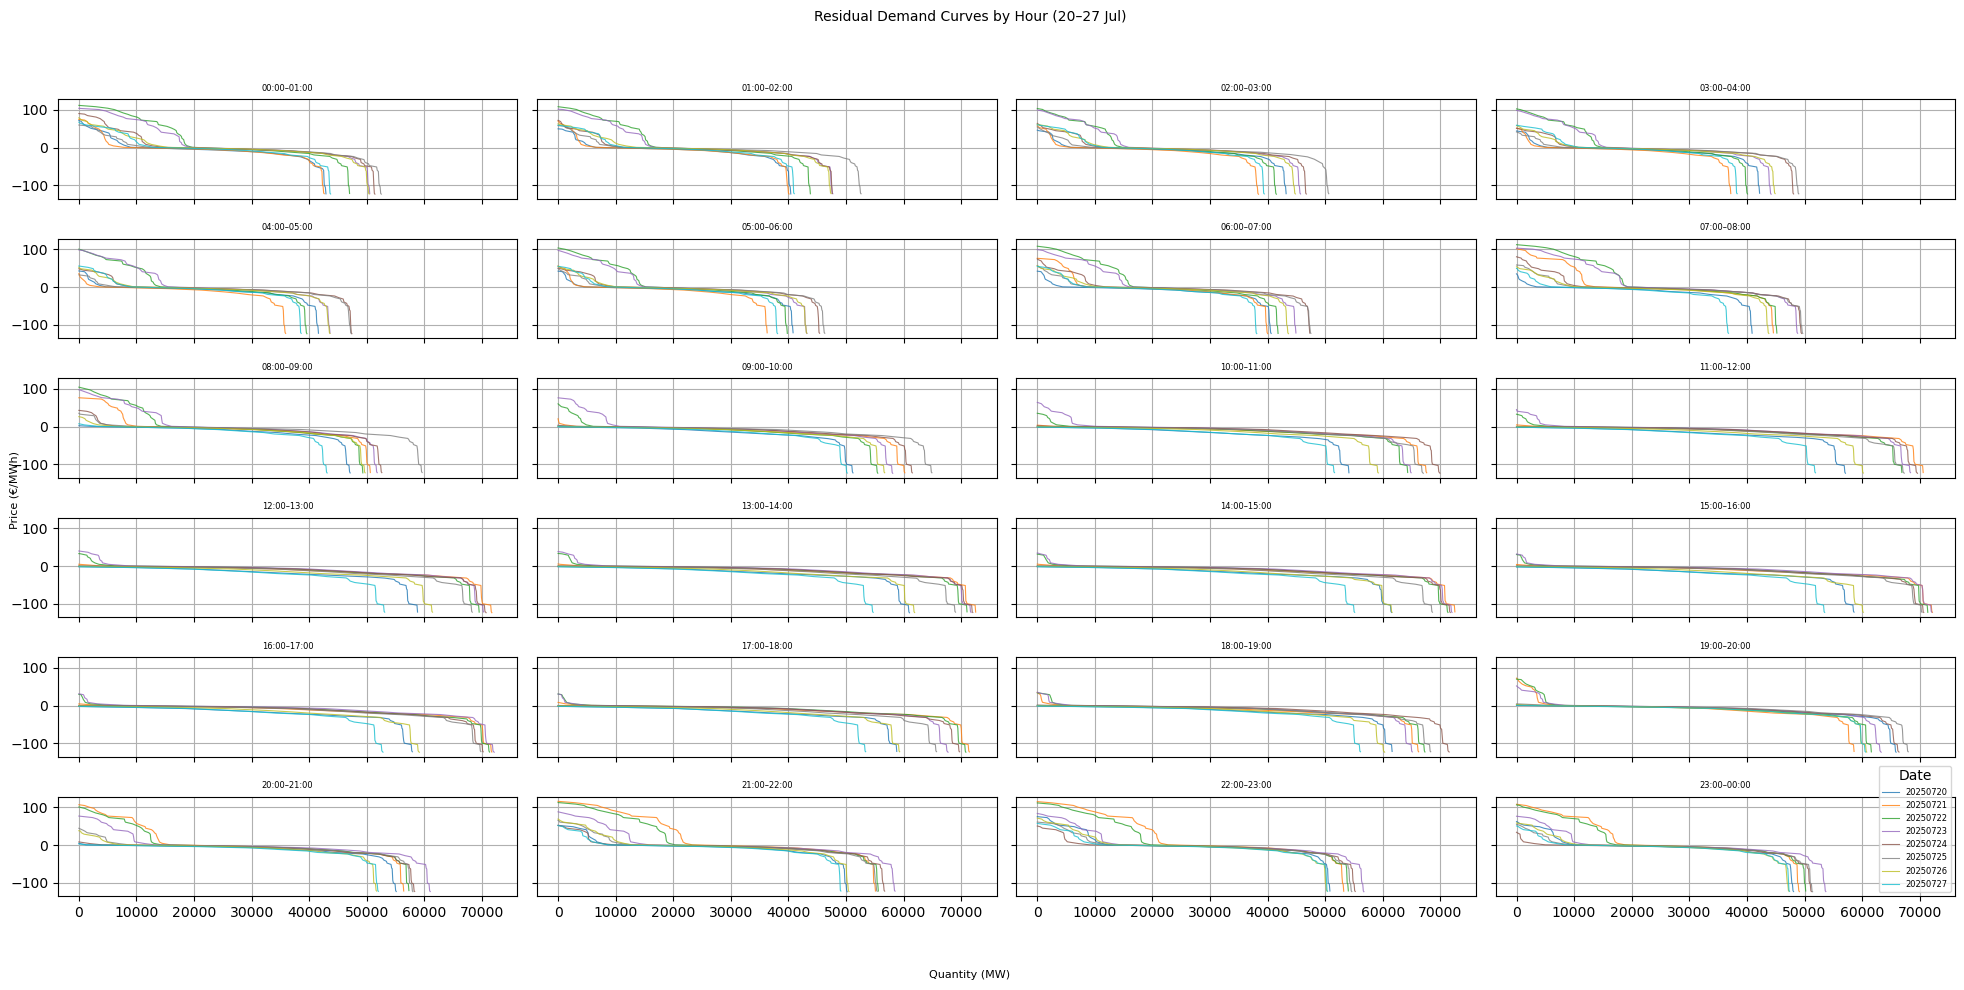

In [16]:

# --- A) RDC 계산 함수 (생략) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i], resid[i+1]
            if r1!=r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q,p_star))
    return rdc

# --- B) 공통 설정 ---
days          = range(20,28)                 # 7/20~7/27
colors        = plt.cm.tab10(np.linspace(0,1,len(days)))
# wf_offer_grid = np.arange(0,20001,100)       # 0,100,…,20000
# wf_offer_grid = np.arange(0, s_agg['Cumul'].max()*1.2, 100)

B             = 1000                           # stepwise 블록 개수

# stepwise 파라미터 저장용
qini            = {}
qmax            = {}
lambda_da_block = {}

# --- C) 4×6 서브플롯 생성 (figsize 10×5) ---
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20,10),
                         sharex=True, sharey=True)
axes = axes.flatten()

# --- D) 각 Period(1~24) 에 대해 ---
for period in range(1,25):
    ax = axes[period-1]
    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"
        try:
            df = pd.read_csv(fn, encoding='utf-8-sig')
        except FileNotFoundError:
            continue

        # 이미 Price/Amount가 float 라고 가정
        sub    = df[df['Time Period']==period]
        sup    = sub[sub['GC']=='V']
        dem    = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 집계 & 누적
        # 집계 & 누적
        s_agg = sup.groupby('Price')['Amount'] \
                    .sum().reset_index() \
                    .sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = dem.groupby('Price')['Amount'] \
                    .sum().reset_index() \
                    .sort_values('Price')
        # 가격 낮을수록 누적이 커져야 하니 역순 누적
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 계단 보간
        s_f = interp1d(
            s_agg['Price'], s_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(0, s_agg['Cumul'].iat[-1])
        )
        d_f = interp1d(
            d_agg['Price'], d_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(d_agg['Cumul'].iat[0], 0)
        )

        pg  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
        sv  = s_f(pg)
        dv  = d_f(pg)

        # 이제야 wf_offer_grid 를 만들 수 있습니다
        wf_offer_grid = np.arange(
            0,
            s_agg['Cumul'].max() * 1.2,
            100
        )
        
        # Residual Demand
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)
        qv = np.array(qv); pv = np.array(pv)

        # ——— stepwise 근사 파라미터 계산 —————————
        q_breaks = np.linspace(0, qv.max(), B+1)
        delta_qs = q_breaks[1:] - q_breaks[:-1]
        for b in range(B):
            mid = 0.5*(q_breaks[b] + q_breaks[b+1])
            # date_str, period, block b 를 키로 사용
            qini   [(date_str, period, b)] = float(q_breaks[b])
            qmax   [(date_str, period, b)] = float(delta_qs[b])
            lambda_da_block[(date_str, period, b)] = float(np.interp(mid, qv, pv))
        # ————————————————————————————————

        # RDC Curve만 플롯
        # ax.plot(qv, pv, 'o-', color=color, label=date_str)
        ax.plot(
            qv, pv,
            '-',                # 실선만
            color=color,
            label=date_str,
            linewidth=0.8,
            alpha=0.8
        )

    # subplot 제목 (예: “00:00–01:00”)
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    ax.set_title(f"{hh1}–{hh2}", fontsize=6)
    ax.grid(True)

# --- E) 공통 레이블 & 레이아웃 ---
fig.supxlabel('Quantity (MW)', fontsize=8)
fig.supylabel('Price (€/MWh)', fontsize=8)
fig.suptitle('Residual Demand Curves by Hour (20–27 Jul)', fontsize=10)

# 범례는 맨 마지막 축에만 표시하도록
axes[-1].legend(title='Date', fontsize=6, loc='lower right')

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


C:\Users\symply_jina\AppData\Local\Temp\ipykernel_9416\3854211120.py:118: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[-1].legend(title='Date', fontsize=6, loc='lower right')


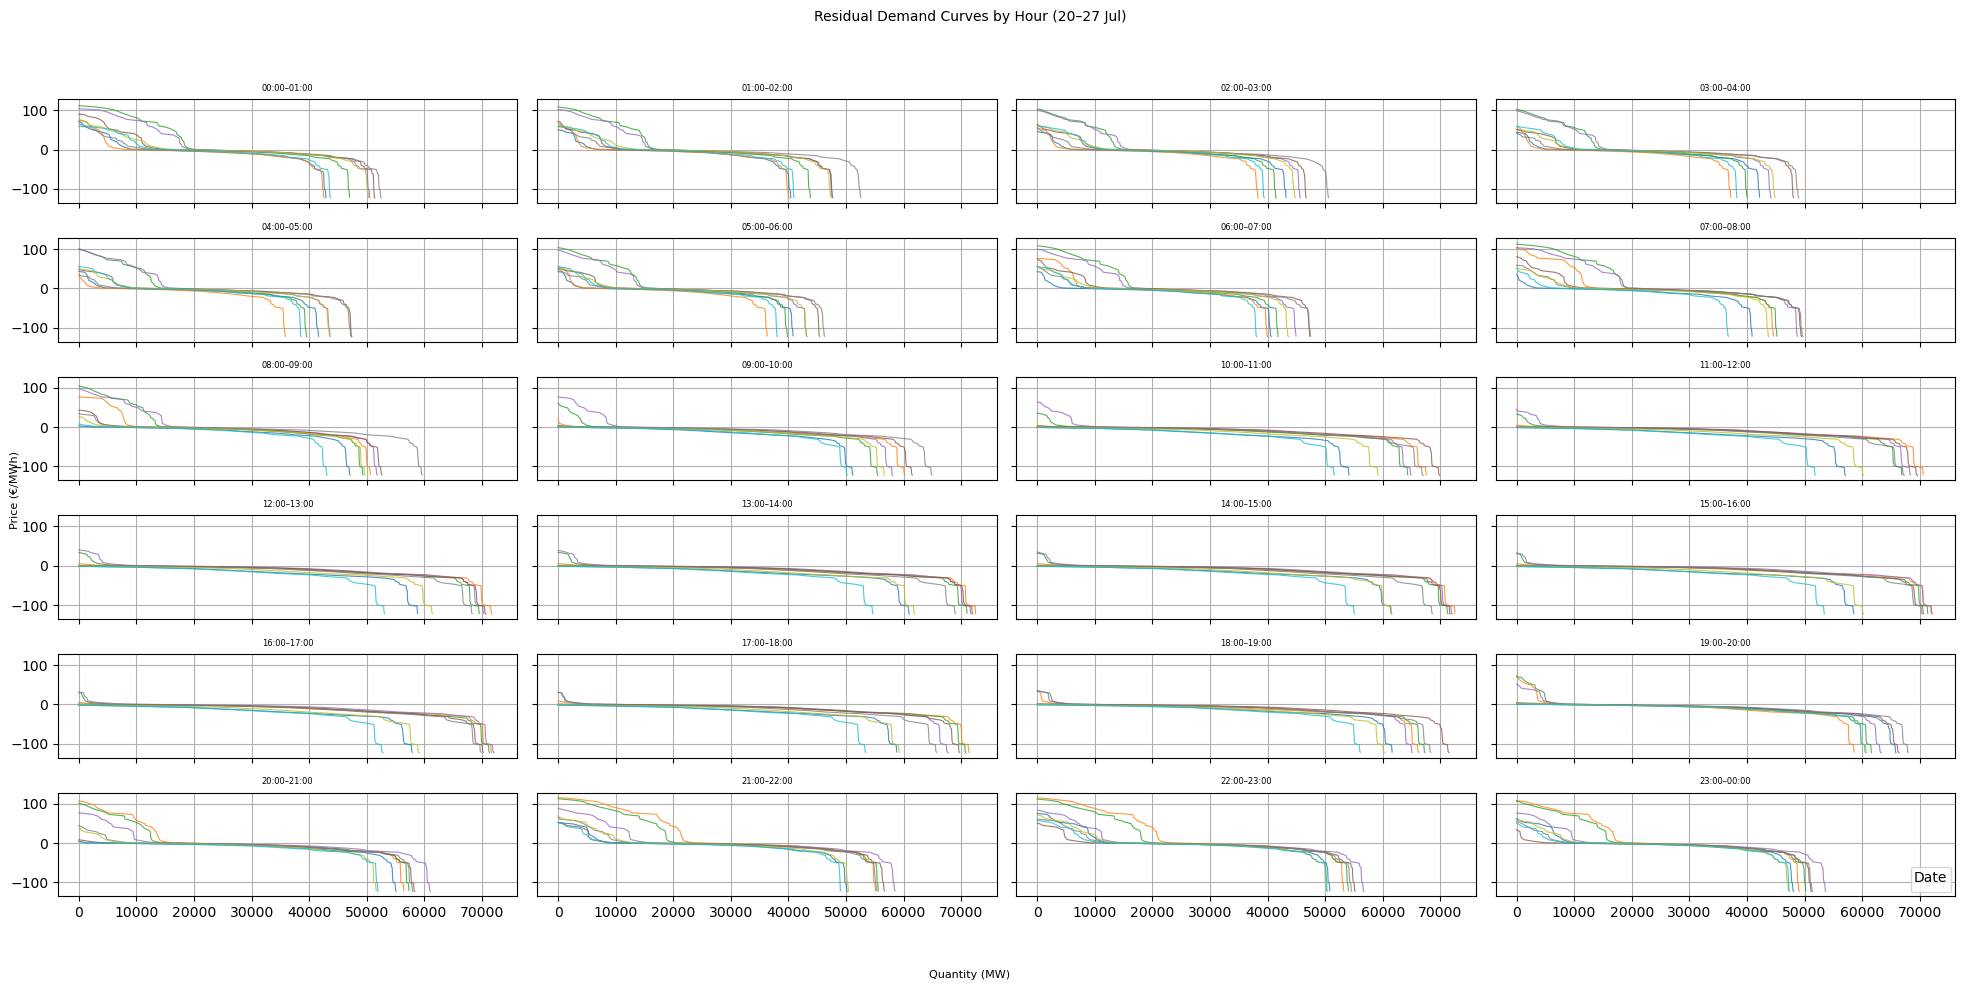

In [ ]:
# #블럭 정의하는대신 그냥 wf_offer_grid 를 사용
# # --- A) RDC 계산 함수 (생략) ---
# def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
#     rdc = []
#     for q in wf_offers:
#         resid = demand_vals - supply_vals - q
#         idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
#         for i in idx:
#             p0,p1 = price_grid[i], price_grid[i+1]
#             r0,r1 = resid[i], resid[i+1]
#             if r1!=r0:
#                 p_star = p0 - r0*(p1-p0)/(r1-r0)
#                 rdc.append((q,p_star))
#     return rdc

# # --- B) 공통 설정 ---
# days          = range(20,28)                 # 7/20~7/27
# colors        = plt.cm.tab10(np.linspace(0,1,len(days)))
# # wf_offer_grid = np.arange(0,20001,100)       # 0,100,…,20000
# # wf_offer_grid = np.arange(0, s_agg['Cumul'].max()*1.2, 100)

# # stepwise 파라미터 저장용
# qini            = {}
# qmax            = {}
# lambda_da_block = {}

# # --- C) 4×6 서브플롯 생성 (figsize 10×5) ---
# fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20,10),
#                          sharex=True, sharey=True)
# axes = axes.flatten()

# # --- D) 각 Period(1~24) 에 대해 ---
# for period in range(1,25):
#     ax = axes[period-1]
#     for day, color in zip(days, colors):
#         date_str = f"202507{day:02d}"
#         fn       = f"filteredcurve_{date_str}.csv"
#         try:
#             df = pd.read_csv(fn, encoding='utf-8-sig')
#         except FileNotFoundError:
#             continue

#         # 이미 Price/Amount가 float 라고 가정
#         sub    = df[df['Time Period']==period]
#         sup    = sub[sub['GC']=='V']
#         dem    = sub[sub['GC']=='C']
#         if sup.empty or dem.empty:
#             continue

#         # 집계 & 누적
#         # 집계 & 누적
#         s_agg = sup.groupby('Price')['Amount'] \
#                     .sum().reset_index() \
#                     .sort_values('Price')
#         s_agg['Cumul'] = s_agg['Amount'].cumsum()

#         d_agg = dem.groupby('Price')['Amount'] \
#                     .sum().reset_index() \
#                     .sort_values('Price')
#         # 가격 낮을수록 누적이 커져야 하니 역순 누적
#         d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

#         # 계단 보간
#         s_f = interp1d(
#             s_agg['Price'], s_agg['Cumul'],
#             kind='previous', bounds_error=False,
#             fill_value=(0, s_agg['Cumul'].iat[-1])
#         )
#         d_f = interp1d(
#             d_agg['Price'], d_agg['Cumul'],
#             kind='previous', bounds_error=False,
#             fill_value=(d_agg['Cumul'].iat[0], 0)
#         )

#         pg  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
#         sv  = s_f(pg)
#         dv  = d_f(pg)

#         wf_offer_grid = np.arange(
#         0,
#         s_agg['Cumul'].max() * 1.2,
#         100
#         )

#         # Residual Demand 계산
#         rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
#         if not rdc_pts:
#             continue
#         qv, pv = zip(*rdc_pts)
#         qv = np.array(qv); pv = np.array(pv)

#         # ——— 블록 수를 wf_offer_grid 단위로 동적으로 설정 —————————
#         n_blocks = len(wf_offer_grid) - 1
#         # q_breaks = [0, max_q/n_blocks, 2*max_q/n_blocks, …, max_q]
#         q_breaks = np.linspace(0, qv.max(), n_blocks+1)
#         delta_qs = q_breaks[1:] - q_breaks[:-1]
#         for b in range(n_blocks):
#             mid = 0.5*(q_breaks[b] + q_breaks[b+1])
#             qini   [(date_str, period, b)] = float(q_breaks[b])
#             qmax   [(date_str, period, b)] = float(delta_qs[b])
#             lambda_da_block[(date_str, period, b)] = float(np.interp(mid, qv, pv))
#         # ——————————————————————————————————————————————

#         # RDC 플롯도 그대로…
#         ax.plot(qv, pv, '-', color=color, linewidth=0.8, alpha=0.8)

#         # subplot 제목 (예: “00:00–01:00”)
#         hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
#         ax.set_title(f"{hh1}–{hh2}", fontsize=6)
#         ax.grid(True)

# # --- E) 공통 레이블 & 레이아웃 ---
# fig.supxlabel('Quantity (MW)', fontsize=8)
# fig.supylabel('Price (€/MWh)', fontsize=8)
# fig.suptitle('Residual Demand Curves by Hour (20–27 Jul)', fontsize=10)

# # 범례는 맨 마지막 축에만 표시하도록
# axes[-1].legend(title='Date', fontsize=6, loc='lower right')

# plt.tight_layout(rect=[0,0.03,1,0.95])
# plt.show()


C:\Users\symply_jina\AppData\Local\Temp\ipykernel_9416\2885647015.py:132: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[-1].legend(title='Date', fontsize=6, loc='lower right')


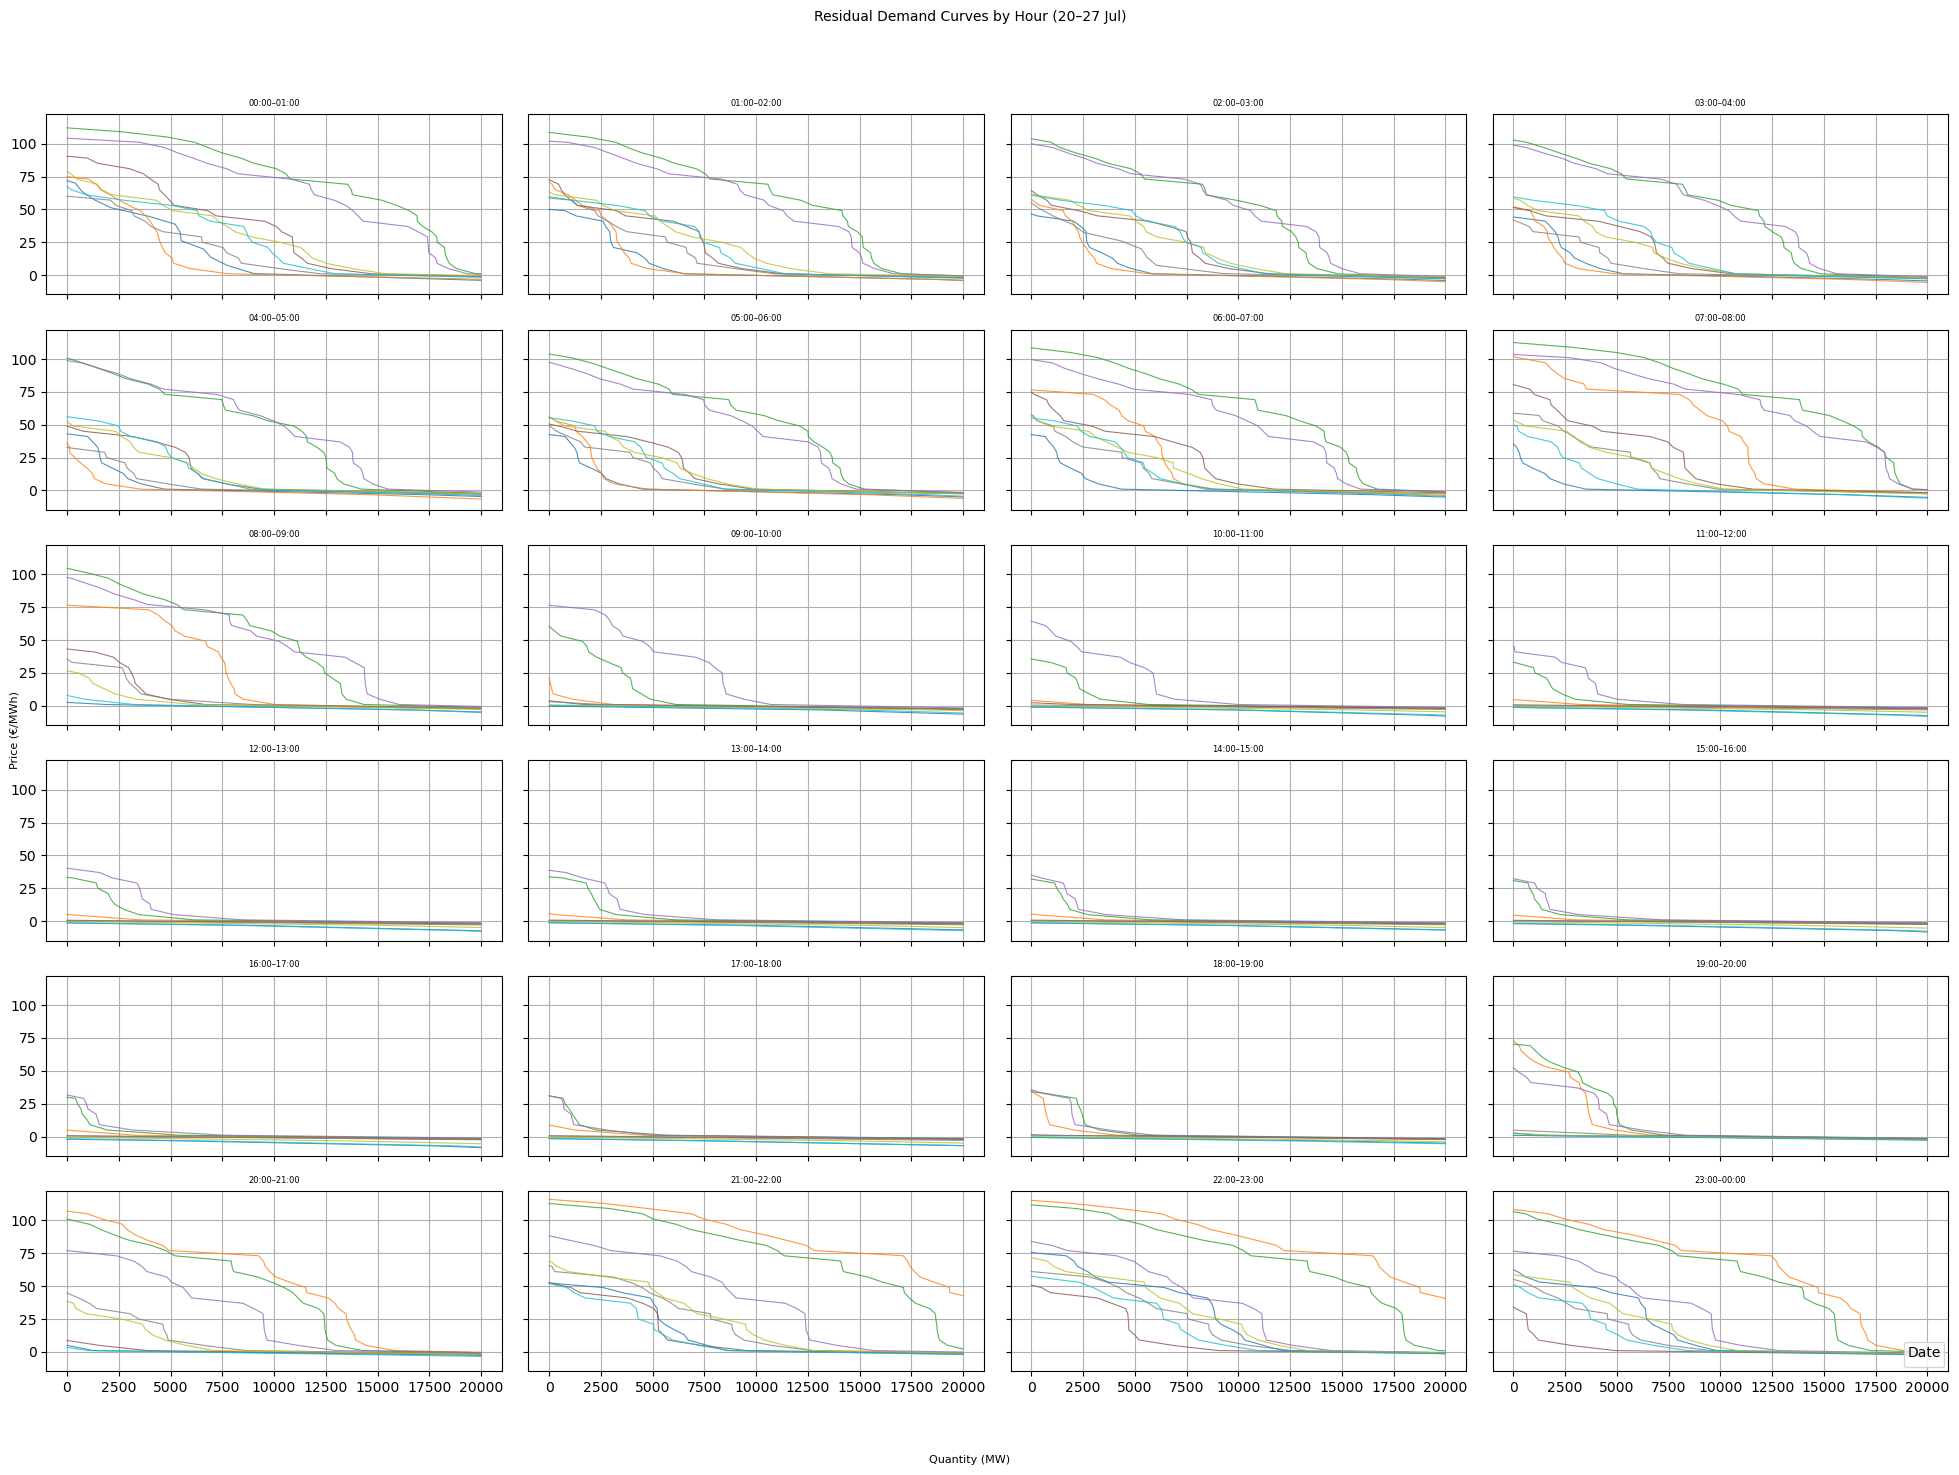

In [33]:
#블럭 정의하는대신 그냥 wf_offer_grid 를 사용
# --- A) RDC 계산 함수 (생략) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i], resid[i+1]
            if r1!=r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q,p_star))
    return rdc

# --- B) 공통 설정 ---
days          = range(20,28)                 # 7/20~7/27
colors        = plt.cm.tab10(np.linspace(0,1,len(days)))
# wf_offer_grid = np.arange(0,20001,100)       # 0,100,…,20000
# wf_offer_grid = np.arange(0, s_agg['Cumul'].max()*1.2, 100)

# stepwise 파라미터 저장용
qini            = {}
qmax            = {}
lambda_da_block = {}
orig_cp         = {}

# --- C) 4×6 서브플롯 생성 (figsize 10×5) ---
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20,15),
                         sharex=True, sharey=True)
axes = axes.flatten()

# --- D) 각 Period(1~24) 에 대해 ---
for period in range(1,25):
    ax = axes[period-1]
    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"
        try:
            df = pd.read_csv(fn, encoding='utf-8-sig')
        except FileNotFoundError:
            continue

        # 이미 Price/Amount가 float 라고 가정
        sub    = df[df['Time Period']==period]
        sup    = sub[sub['GC']=='V']
        dem    = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 집계 & 누적
        # 집계 & 누적
        s_agg = sup.groupby('Price')['Amount'] \
                    .sum().reset_index() \
                    .sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = dem.groupby('Price')['Amount'] \
                    .sum().reset_index() \
                    .sort_values('Price')
        # 가격 낮을수록 누적이 커져야 하니 역순 누적
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 계단 보간
        s_f = interp1d(
            s_agg['Price'], s_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(0, s_agg['Cumul'].iat[-1])
        )
        d_f = interp1d(
            d_agg['Price'], d_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(d_agg['Cumul'].iat[0], 0)
        )

        pg  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
        sv  = s_f(pg)
        dv  = d_f(pg)
        
        #Original Clearing Price 계산
        def resid0(p): 
            return d_f(p) - s_f(p)   # q=0
        sol0 = root_scalar(resid0,
                           bracket=[pg[0], pg[-1]],
                           method='bisect')
        orig_cp[(date_str, period)] = sol0.root if sol0.converged else np.nan

        # Residual Demand 계산
        # wf_offer_grid = np.arange(
        # 0,
        # s_agg['Cumul'].max() * 1.2,
        # 100
        # )
        wf_offer_grid = np.arange(
        0,
        20000,
        5
        )

        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)
        qv = np.array(qv); pv = np.array(pv)

        # ——— 블록 수를 wf_offer_grid 단위로 동적으로 설정 —————————
        n_blocks = len(wf_offer_grid) - 1
        # q_breaks = [0, max_q/n_blocks, 2*max_q/n_blocks, …, max_q]
        q_breaks = np.linspace(0, qv.max(), n_blocks+1)
        delta_qs = q_breaks[1:] - q_breaks[:-1]
        for b in range(n_blocks):
            mid = 0.5*(q_breaks[b] + q_breaks[b+1])
            qini   [(date_str, period, b)] = float(q_breaks[b])
            qmax   [(date_str, period, b)] = float(delta_qs[b])
            lambda_da_block[(date_str, period, b)] = float(np.interp(mid, qv, pv))
        # ——————————————————————————————————————————————

        # RDC 플롯도 그대로…
        ax.plot(qv, pv, '-', color=color, linewidth=0.8, alpha=0.8)

        # subplot 제목 (예: “00:00–01:00”)
        hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
        ax.set_title(f"{hh1}–{hh2}", fontsize=6)
        ax.grid(True)

# --- E) 공통 레이블 & 레이아웃 ---
fig.supxlabel('Quantity (MW)', fontsize=8)
fig.supylabel('Price (€/MWh)', fontsize=8)
fig.suptitle('Residual Demand Curves by Hour (20–27 Jul)', fontsize=10)

# 범례는 맨 마지막 축에만 표시하도록
axes[-1].legend(title='Date', fontsize=6, loc='lower right')

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


In [25]:
records = [
    {"date": d, "period": t, "orig_cp": orig_cp[(d,t)]}
    for d in [f"202507{day:02d}" for day in days]
    for t in range(1,25)
]
df_orig = pd.DataFrame(records)
print(df_orig)

         date  period       orig_cp
0    20250720       1  7.490000e+01
1    20250720       2  5.022000e+01
2    20250720       3  4.548000e+01
3    20250720       4  4.498000e+01
4    20250720       5  4.407000e+01
5    20250720       6  4.394000e+01
6    20250720       7  4.394000e+01
7    20250720       8  3.500000e+01
8    20250720       9  3.520000e+00
9    20250720      10 -1.776357e-12
10   20250720      11 -4.700000e-01
11   20250720      12 -6.000000e-01
12   20250720      13 -6.200000e-01
13   20250720      14 -6.000000e-01
14   20250720      15 -6.200000e-01
15   20250720      16 -1.210000e+00
16   20250720      17 -2.000000e+00
17   20250720      18 -1.210000e+00
18   20250720      19 -1.000000e-02
19   20250720      20  1.000000e+00
20   20250720      21  5.000000e+00
21   20250720      22  5.200000e+01
22   20250720      23  7.602000e+01
23   20250720      24  6.294000e+01
24   20250721       1  7.513000e+01
25   20250721       2  6.999000e+01
26   20250721       3  5.765

In [154]:
# df = pd.read_csv('fixed_pricesamount.csv')
# # 3) 원하는 기간 필터
# period = 2
# mask = df['Time Period'] == period
# supply = df[mask & (df['GC'] == 'V')].copy()
# demand = df[mask & (df['GC'] == 'C')].copy()

# # 4) 공급 집계 (오름차순)
# supply_agg = (
#     supply.groupby('Price')['Amount']
#           .sum()
#           .reset_index()
#           .sort_values('Price')
# )
# supply_agg['CumulQty'] = supply_agg['Amount'].cumsum()

# # 5) 수요 집계 (오름차순으로 정렬 후 역순 누적)
# demand_agg = (
#     demand.groupby('Price')['Amount']
#           .sum()
#           .reset_index()
#           .sort_values('Price')
# )
# # 가격이 낮을수록 누적 수요가 많아지도록 역순 누적
# demand_agg['CumulQty'] = demand_agg['Amount'][::-1].cumsum()[::-1]

# # 6) 보간 함수 정의 (x: Price 오름차순)
# supply_func = interp1d(
#     supply_agg['Price'],
#     supply_agg['CumulQty'],
#     kind='previous',
#     bounds_error=False,
#     fill_value=(0, supply_agg['CumulQty'].iloc[-1])
# )
# demand_func = interp1d(
#     demand_agg['Price'],
#     demand_agg['CumulQty'],
#     kind='previous',
#     bounds_error=False,
#     fill_value=(demand_agg['CumulQty'].iloc[0], 0)
# )

# # 7) 보간용 price grid
# price_grid = np.linspace(
#     min(supply_agg['Price'].min(), demand_agg['Price'].min()),
#     max(supply_agg['Price'].max(), demand_agg['Price'].max()),
#     500
# )

# # 8) 보간된 누적량 계산
# supply_vals = supply_func(price_grid)
# demand_vals = demand_func(price_grid)

# # 9) 플롯 (x: 누적량, y: 가격)
# plt.figure(figsize=(8,5))
# plt.plot(supply_vals, price_grid, label='Supply Curve')
# plt.plot(demand_vals, price_grid, label='Demand Curve')
# plt.xlabel('Cumulative Quantity')
# plt.ylabel('Price')
# plt.title('Interpolated Supply & Demand Curves')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [84]:
# def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
#     """
#     price_grid, demand_vals, supply_vals 는 같은 길이의 1D array.
#     wf_offers: 풍력 입찰량(q) 리스트/배열
#     """
#     rdc = []
#     # residual(p) 를 price_grid 위에서 미리 계산할 것이므로 D_vals, S_vals = demand_vals, supply_vals
#     for q in wf_offers:
#         # 잔여수요 residual 값들
#         resid = demand_vals - supply_vals - q

#         # 연속된 구간에서 부호가 바뀌는 지점을 찾는다
#         # np.diff(np.sign(resid)) != 0 인 인덱스
#         idx = np.where(np.diff(np.sign(resid)) != 0)[0]

#         if len(idx) == 0:
#             # 교차가 없으면 root 못 찾음 → 건너뛴다
#             continue

#         # 각 구간마다 하나씩, 선형보간으로 p_star 계산
#         for i in idx:
#             p0, p1 = price_grid[i],     price_grid[i+1]
#             r0, r1 = resid[i],          resid[i+1]

#             # (p* - p0) / (p1 - p0) = -r0/(r1 - r0)
#             # → p* = p0 - r0*(p1-p0)/(r1-r0)
#             if r1 != r0:
#                 p_star = p0 - r0 * (p1 - p0) / (r1 - r0)
#                 rdc.append((q, p_star))
#             # 만약 r1==r0 면 skip

#     return rdc

# # 사용 예:
# wf_offer_grid = np.linspace(0, supply_agg['CumulQty'].max(), 30)
# rdc_pts = compute_rdc_by_sign_change(
#     price_grid, demand_vals, supply_vals, wf_offer_grid
# )

# # q_vals, p_vals 언팩
# q_vals, p_vals = zip(*rdc_pts)

# # 시각화
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,6))
# plt.step(supply_vals,  price_grid, where='post', label='Supply', color='gray')
# plt.step(demand_vals,  price_grid, where='post', label='Demand', color='silver')
# plt.plot(q_vals, p_vals, 'o-', label='Residual Demand', color='blue')
# plt.xlabel('Quantity (MW)')
# plt.ylabel('Price (€/MWh)')
# plt.title(f'Residual Demand Curve (Period {period})')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [117]:
# # 5) 원하는 시간대(period) 필터
# period = 2
# mask = df['Time Period'] == period
# supply = df[mask & (df['GC'] == 'V')].copy()  # 판매 입찰
# demand = df[mask & (df['GC'] == 'C')].copy()  # 구매 입찰

# # 6) 가격별 집계 및 누적합 계산
# # 6-1) 공급곡선: Price 오름차순 → 누적합
# supply_agg = (
#     supply.groupby('Price')['Amount']
#           .sum()
#           .reset_index()
#           .sort_values('Price')
# )
# supply_agg['CumulQty'] = supply_agg['Amount'].cumsum()

# # 6-2) 수요곡선: Price 오름차순 정렬 → 역순 누적 → 제자리 역순
# demand_agg = (
#     demand.groupby('Price')['Amount']
#           .sum()
#           .reset_index()
#           .sort_values('Price')
# )
# demand_agg['CumulQty'] = demand_agg['Amount'][::-1].cumsum()[::-1]

# # 7) 보간 함수 정의 (계단형: kind='previous')
# supply_func = interp1d(
#     supply_agg['Price'], supply_agg['CumulQty'],
#     kind='previous', bounds_error=False,
#     fill_value=(0, supply_agg['CumulQty'].iloc[-1])
# )
# demand_func = interp1d(
#     demand_agg['Price'], demand_agg['CumulQty'],
#     kind='previous', bounds_error=False,
#     fill_value=(demand_agg['CumulQty'].iloc[0], 0)
# )

# # 8) 보간용 price grid (500점)
# price_grid = np.linspace(
#     min(supply_agg['Price'].min(), demand_agg['Price'].min()),
#     max(supply_agg['Price'].max(), demand_agg['Price'].max()),
#     500
# )

# supply_vals = supply_func(price_grid)
# demand_vals = demand_func(price_grid)

# # 9) 시각화
# plt.figure(figsize=(10,6))
# plt.plot(supply_vals, price_grid, label='Supply Curve', linewidth=2)
# plt.plot(demand_vals, price_grid, label='Demand Curve', linewidth=2)
# plt.xlabel('Cumulative Quantity')
# plt.ylabel('Price')
# plt.title(f'Interpolated Supply & Demand Curves (Period {period})')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

### KDE 

In [1]:
# # ① 반복할 날짜, period 설정
# period = 2
# days = range(20,28)

# price_list_d = []
# weight_list_d = []
# price_list_s = []
# weight_list_s = []

# for day in days:
#     date_str = f"202507{day:02d}"
#     fn = f"filteredcurve_{date_str}.csv"
#     try:
#         df = pd.read_csv(fn, encoding='utf-8-sig')
#     except FileNotFoundError:
#         continue
    
#     # ② period 필터링
#     mask = df['Time Period'] == period
#     sup = df[mask & (df['GC']=='V')]
#     dem = df[mask & (df['GC']=='C')]
    
#     # ③ 가격별 집계
#     sup_agg = (
#       sup.groupby('Price')['Amount']
#          .sum().reset_index()
#     )
#     dem_agg = (
#       dem.groupby('Price')['Amount']
#          .sum().reset_index()
#     )
    
#     # ④ 배열에 누적
#     price_list_s.append(sup_agg['Price'].values)
#     weight_list_s.append(sup_agg['Amount'].values)
#     price_list_d.append(dem_agg['Price'].values)
#     weight_list_d.append(dem_agg['Amount'].values)

# # ⑤ 1D 배열로 변환
# price_obs_d   = np.concatenate(price_list_d)
# weight_obs_d  = np.concatenate(weight_list_d)
# price_obs_s   = np.concatenate(price_list_s)
# weight_obs_s  = np.concatenate(weight_list_s)


In [ ]:
# from sklearn.neighbors import KernelDensity
# from sklearn.model_selection import GridSearchCV

# # ① 밴드폭 CV 그리드 서치
# def select_bw(prices, weights, grid):
#     pr = prices.reshape(-1,1)
#     gs = GridSearchCV(KernelDensity(kernel='gaussian'),
#                       {'bandwidth': grid}, cv=5)
#     gs.fit(pr, sample_weight=weights)
#     return gs.best_params_['bandwidth']

# bw_d = select_bw(price_obs_d, weight_obs_d, np.linspace(0.5,5,20))
# bw_s = select_bw(price_obs_s, weight_obs_s, np.linspace(0.5,5,20))

# # ② KDE 학습
# kde_d = KernelDensity(kernel='gaussian', bandwidth=bw_d).fit(
#             price_obs_d.reshape(-1,1),
#             sample_weight=weight_obs_d
#          )
# kde_s = KernelDensity(kernel='gaussian', bandwidth=bw_s).fit(
#             price_obs_s.reshape(-1,1),
#             sample_weight=weight_obs_s
#          )

In [2]:

# # --- (1) CSV에서 실(curve) 집계 ---  
# df = pd.read_csv("filteredcurve_20250720.csv", encoding='utf-8-sig')
# period = 2
# mask = df['Time Period']==period
# sup = df[mask & (df['GC']=='V')]; dem = df[mask & (df['GC']=='C')]

# # 가격별 누적량(step curve)
# sup_agg = sup.groupby('Price')['Amount'].sum().sort_index().cumsum()
# dem_agg = dem.groupby('Price')['Amount'].sum().sort_index()[::-1].cumsum()[::-1]

# # 실제 곡선 그리기 위한 스텝 포인트
# price_actual_s = sup_agg.index.values
# qty_actual_s   = sup_agg.values
# price_actual_d = dem_agg.index.values
# qty_actual_d   = dem_agg.values

# # --- (2) KDE 학습을 위한 배열 준비 ---  
# price_obs_s = np.repeat(price_actual_s, qty_actual_s.astype(int))
# price_obs_d = np.repeat(price_actual_d, qty_actual_d.astype(int))

# # 밴드폭 최적화
# def select_bw(x):
#     grid = {'bandwidth': np.linspace(0.5,5,20)}
#     gs = GridSearchCV(KernelDensity(kernel='gaussian'), grid, cv=5)
#     return gs.fit(x.reshape(-1,1)).best_params_['bandwidth']

# bw_s = select_bw(price_obs_s)
# bw_d = select_bw(price_obs_d)

# kde_s = KernelDensity(bandwidth=bw_s).fit(price_obs_s.reshape(-1,1))
# kde_d = KernelDensity(bandwidth=bw_d).fit(price_obs_d.reshape(-1,1))

# # --- (3) KDE → 누적량 curve 변환 ---  
# price_grid = np.linspace(min(price_actual_s.min(), price_actual_d.min()),
#                          max(price_actual_s.max(), price_actual_d.max()), 500)

# def kde_to_qty(kde, total_qty, grid):
#     log_d = kde.score_samples(grid.reshape(-1,1))
#     dens  = np.exp(log_d)
#     cdf   = np.cumsum(dens)
#     return total_qty * cdf / cdf[-1]

# Qtot_s = qty_actual_s.sum()
# Qtot_d = qty_actual_d.sum()
# qty_kde_s = kde_to_qty(kde_s, Qtot_s, price_grid)
# qty_kde_d = kde_to_qty(kde_d, Qtot_d, price_grid)

# # --- (4) 비교 플롯 ---  
# plt.figure(figsize=(8,6))

# # 실제 스텝 곡선
# plt.step(qty_actual_s, price_actual_s, where='post', color='C0', label='Actual Supply')
# plt.step(qty_actual_d, price_actual_d, where='post', color='C1', label='Actual Demand')

# # KDE 추정 곡선
# plt.plot(qty_kde_s, price_grid, color='C0', linestyle='--', linewidth=2, label='KDE Supply')
# plt.plot(qty_kde_d, price_grid, color='C1', linestyle='--', linewidth=2, label='KDE Demand')

# plt.xlabel("Cumulative Quantity (MW)")
# plt.ylabel("Price ($/MWh)")
# plt.title("Actual vs. KDE-Estimated Supply & Demand Curves")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()


### Day Ahead Commitment

Parameter Setting

In [17]:
import gurobipy as gp
from gurobipy import GRB

In [18]:
# ─────────────────────────────────────────────────────────────
# 5) 모델 파라미터 및 시나리오 생성
# ─────────────────────────────────────────────────────────────

# 시간, 시나리오, 풍력 설비 인덱스
T = list(range(24))   # 24시간
S = list(range(8))   # 시나리오
I = list(range(1))    # 1개 풍력 설비

# ESS 파라미터
eta_c, eta_d    = 0.9, 0.9
E0, E_min, E_max = 1400, 500, 2250
pc_max, pd_max  = 500, 500

# RDC 블록 파라미터
qini = {(t,b): float(q_breaks[b]) for t in T for b in range(B)}
qmax = {(t,b): float(delta_qs[b])   for t in T for b in range(B)}

# 풍력 발전량 시나리오 pwf[i,t,s]
np.random.seed(0)
Cw = 1000
pwf = {
    (i,t,s): max(0, np.random.normal(Cw*0.35, Cw*0.10))
    for i in I for t in T for s in S
}

rho = {s: 1/len(S) for s in S}

0720 예시로 하나: deterministic

In [26]:
# 2) 7월 20일만 뽑아낼 date_sel 정의
date_sel = "20250720"

qini20 = { (t,b): val 
           for (d,t,b), val in qini.items() 
           if d == date_sel }
qmax20 = { (t,b): val 
           for (d,t,b), val in qmax.items() 
           if d == date_sel }
lam20  = { (t,b): val 
           for (d,t,b), val in lambda_da_block.items() 
           if d == date_sel }

# 3) 시간대 T, 블록 최댓값 B_full
T      = list(range(1,25))
B_full = 1000

# 4) valid_blocks: qmax20>0 인 (t,b) 만
valid_blocks = {
    t: [ b for (tt,b) in qmax20.keys() if tt == t and qmax20[(tt,b)]>0 ]
    for t in T
}

# 5) Gurobi 모델 생성
m = gp.Model("WF_20250720_DA")

# 6) 변수 선언
u    = m.addVars(
    [(t,b) for t in T for b in valid_blocks[t]],
    vtype=GRB.BINARY, name="u"
)
qvar = m.addVars(
    [(t,b) for t in T for b in valid_blocks[t]],
    lb=0.0, name="qvar"
)

# 7) 목적함수
m.setObjective(
    gp.quicksum(
        lam20[(t,b)] * (u[t,b]*qini20[(t,b)] + qvar[t,b])
        for t in T for b in valid_blocks[t]
    ),
    GRB.MAXIMIZE
)

# 8) 제약조건
for t in T:
    blks = valid_blocks[t]
    # (2c) 하나의 블록만 선택
    m.addConstr(
        gp.quicksum(u[t,b] for b in blks) == 1,
        name=f"one_block_{t}"
    )
    # (2d) qvar <= qmax * u
    for b in blks:
        m.addConstr(
            qvar[t,b] <= qmax20[(t,b)] * u[t,b],
            name=f"qvar_valid_{t}_{b}"
        )

# 9) 옵션 및 최적화
m.Params.TimeLimit  = 60
m.Params.OutputFlag = 1
m.optimize()

# 10) 결과 확인
if m.status in {GRB.OPTIMAL, GRB.TIME_LIMIT}:
    print(f"\n=== DA Objective for {date_sel}: {m.ObjVal:.2f} ===\n")
    for t in T:
        for b in valid_blocks[t]:
            if u[t,b].X > 0.5:
                print(
                    f"Hour {t:02d}: block={b}, "
                    f"q_ini={qini20[(t,b)]:.1f}, "
                    f"q_var={qvar[t,b].X:.1f}, "
                    f"λ_da={lam20[(t,b)]:.2f}"
                )


Set parameter TimeLimit to value 60
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 28668 rows, 57288 columns and 85932 nonzeros
Model fingerprint: 0x312a89ec
Variable types: 28644 continuous, 28644 integer (28644 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+01]
  Objective range  [5e-04, 8e+06]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective -1.46404e+07
Presolve removed 28654 rows and 57274 columns
Presolve time: 0.02s
Presolved: 14 rows, 14 columns, 14 nonzeros
Found heuristic solution: objective 1415847.9701
Variable types: 0 continuous, 14 integer (14 binary)

Explored 0 nodes (0 simplex iterations) in 0.03 seconds (0.03 work units)
Thread count was 32 (of 32 available processors)

Solution cou

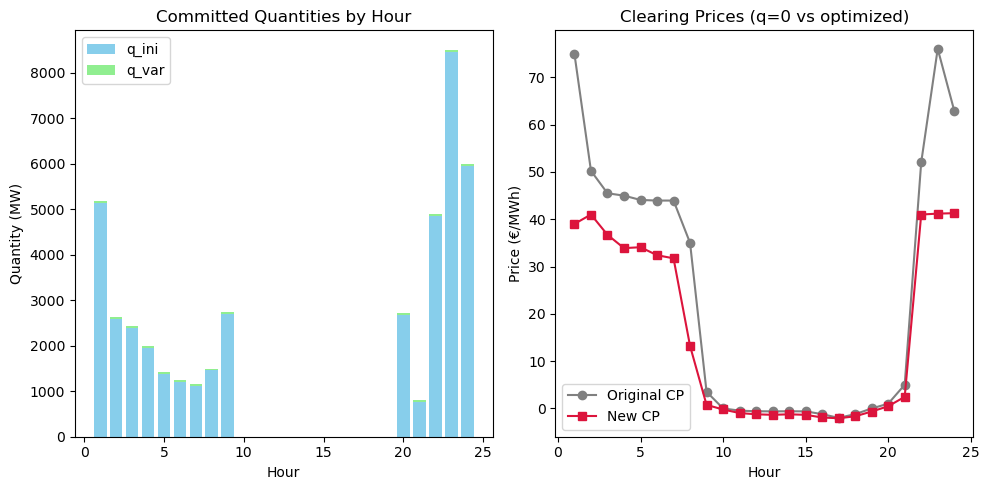

In [27]:

# --- A) 재계산: Supply/Demand 곡선 & original CP ---
price_grid = np.linspace(0, 3000, 500)  # 충분히 넓게 잡으세요
orig_cp = {}
# 미리 곡선 함수 생성
s_funcs = {}
d_funcs = {}
df20 = pd.read_csv("filteredcurve_20250720.csv", encoding="utf-8-sig")
for t in range(1,25):
    sub = df20[df20["Time Period"]==t]
    sup = sub[sub["GC"]=="V"].groupby("Price")["Amount"].sum().reset_index()
    dem = sub[sub["GC"]=="C"].groupby("Price")["Amount"].sum().reset_index()
    if sup.empty or dem.empty:
        continue
    # 누적
    sup = sup.sort_values("Price")
    sup["Cumul"] = sup["Amount"].cumsum()
    dem = dem.sort_values("Price")
    dem["Cumul"] = dem["Amount"][::-1].cumsum()[::-1]
    # 계단 보간
    s_funcs[t] = interp1d(sup["Price"], sup["Cumul"],
                          kind="previous", bounds_error=False,
                          fill_value=(0, sup["Cumul"].iat[-1]))
    d_funcs[t] = interp1d(dem["Price"], dem["Cumul"],
                          kind="previous", bounds_error=False,
                          fill_value=(dem["Cumul"].iat[0], 0))
    # original CP: solve D(p)-S(p)=0
    def resid(p): return d_funcs[t](p) - s_funcs[t](p)
    sol = root_scalar(resid, bracket=[sup["Price"].min(), dem["Price"].max()])
    orig_cp[t] = sol.root if sol.converged else np.nan

# --- B) 결과 데이터 수집 ---
hours   = list(range(1,25))
ini_qty = []
var_qty = []
new_cp  = []
for t in hours:
    # 선택된 block
    b_sel = next((b for b in valid_blocks[t] if u[t,b].X > 0.5), None)
    if b_sel is None:
        ini_qty.append(0)
        var_qty.append(0)
        new_cp .append(np.nan)
    else:
        ini_qty.append(qini20[(t,b_sel)])
        var_qty.append(qvar[t,b_sel].X)
        new_cp .append(lam20 [(t,b_sel)])

orig_cp_list = [orig_cp.get(t, np.nan) for t in hours]

# --- C) 시각화 ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

# C1) 스택바: initial vs var
ax1 = axes[0]
ax1.bar(hours, ini_qty,     label="q_ini",  color="skyblue")
ax1.bar(hours, var_qty, bottom=ini_qty,
        label="q_var", color="lightgreen")
ax1.set_xlabel("Hour")
ax1.set_ylabel("Quantity (MW)")
ax1.set_title("Committed Quantities by Hour")
ax1.legend()

# C2) 원/신 청산가격 비교
ax2 = axes[1]
ax2.plot(hours, orig_cp_list, 'o-', label="Original CP", color="gray")
ax2.plot(hours, new_cp,      's-', label="New CP",      color="crimson")
ax2.set_xlabel("Hour")
ax2.set_ylabel("Price (€/MWh)")
ax2.set_title("Clearing Prices (q=0 vs optimized)")
ax2.legend()

plt.tight_layout()
plt.show()


Original clearing price (7/20):
 Hour 01: p* = 74.90
 Hour 02: p* = 50.22
 Hour 03: p* = 45.48
 Hour 04: p* = 44.98
 Hour 05: p* = 44.07
 Hour 06: p* = 43.94
 Hour 07: p* = 43.94
 Hour 08: p* = 35.00
 Hour 09: p* = 3.52
 Hour 10: p* = -0.00
 Hour 11: p* = -0.47
 Hour 12: p* = -0.60
 Hour 13: p* = -0.62
 Hour 14: p* = -0.60
 Hour 15: p* = -0.62
 Hour 16: p* = -1.21
 Hour 17: p* = -2.00
 Hour 18: p* = -1.21
 Hour 19: p* = -0.01
 Hour 20: p* = 1.00
 Hour 21: p* = 5.00
 Hour 22: p* = 52.00
 Hour 23: p* = 76.02
 Hour 24: p* = 62.94
Set parameter TimeLimit to value 60
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 0 rows, 24 columns and 0 nonzeros
Model fingerprint: 0x0b027183
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  Objective range  [2e-12, 8e+01]
  Bounds

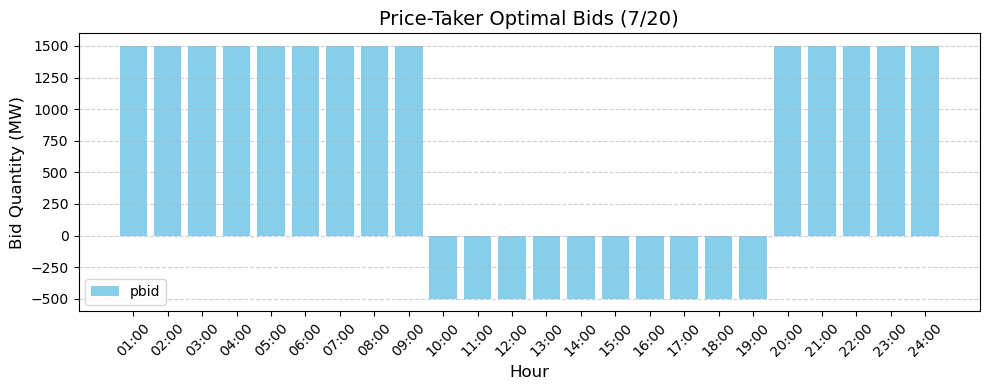

In [23]:
# Price Taker

# --- 1) original CP 재계산 (7/20 데이터 기준) ----------------------------
df20 = pd.read_csv("filteredcurve_20250720.csv", encoding="utf-8-sig")

# supply/demand 누적곡선 함수 저장
s_funcs = {}
d_funcs = {}
orig_cp = {}

for t in range(1,25):
    sub = df20[df20["Time Period"]==t]
    sup = ( sub[sub["GC"]=="V"]
            .groupby("Price")["Amount"]
            .sum().reset_index()
            .sort_values("Price") )
    dem = ( sub[sub["GC"]=="C"]
            .groupby("Price")["Amount"]
            .sum().reset_index()
            .sort_values("Price") )
    if sup.empty or dem.empty:
        orig_cp[t] = np.nan
        continue

    sup["Cumul"] = sup["Amount"].cumsum()
    dem["Cumul"] = dem["Amount"][::-1].cumsum()[::-1]

    # 계단형 보간
    s_funcs[t] = interp1d(
        sup["Price"], sup["Cumul"],
        kind="previous", bounds_error=False,
        fill_value=(0, sup["Cumul"].iat[-1])
    )
    d_funcs[t] = interp1d(
        dem["Price"], dem["Cumul"],
        kind="previous", bounds_error=False,
        fill_value=(dem["Cumul"].iat[0], 0)
    )

    # root 찾기: D(p) - S(p) = 0
    def resid(p): return d_funcs[t](p) - s_funcs[t](p)
    bracket = [sup["Price"].min(), dem["Price"].max()]
    sol = root_scalar(resid, bracket=bracket, method="bisect")
    orig_cp[t] = sol.root if sol.converged else np.nan

# 확인
print("Original clearing price (7/20):")
for t in range(1,25):
    print(f" Hour {t:02d}: p* = {orig_cp[t]:.2f}")
    

# --- 2) Price-Taker Model 구성 ------------------------------------------
T = list(range(1,25))

m = gp.Model("WF_20250720_PT")

# (A) 입찰량 변수: pbid[t] ∈ [-500, 1500]
pbid = m.addVars(
    T,
    lb=-500, ub=1500,
    name="pbid"
)

# (B) 목적함수: ∑ orig_cp[t] * pbid[t]
m.setObjective(
    gp.quicksum(orig_cp[t] * pbid[t] for t in T),
    GRB.MAXIMIZE
)

# (C) 아무 추가 제약 없으면 여기까지
#     ※ 필요한 경우 (예: 예산, 용량, ramp 등) 추가하세요.

# (D) 옵션 & 최적화
m.Params.TimeLimit  = 60
m.Params.OutputFlag = 1
m.optimize()

# --- 3) 결과 출력 & 시각화 ----------------------------------------------
if m.status in {GRB.OPTIMAL, GRB.TIME_LIMIT}:
    # 데이터프레임으로 모아서 출력
    import pandas as pd
    recs = []
    for t in T:
        q = pbid[t].X
        p = orig_cp[t]
        recs.append({
            "Hour":      t,
            "p* (€/MWh)": round(p,2),
            "pbid (MW)": round(q,2),
            "Revenue":   round(p*q,2)
        })
    df_res = pd.DataFrame(recs)
    pd.set_option('display.max_rows', None)
    print(df_res)
    
    # 시각화
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,4))
    plt.bar(df_res["Hour"], df_res["pbid (MW)"],
            color='skyblue', label='pbid')
    plt.xlabel("Hour", fontsize=12)
    plt.ylabel("Bid Quantity (MW)", fontsize=12)
    plt.title("Price-Taker Optimal Bids (7/20)", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.xticks(T, [f"{h:02d}:00" for h in T], rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()



Scenario로 고려: 20-27일 rdc 가져와서

In [165]:


# --- A) 시나리오 정의 ---------------------------------------------------
days     = list(range(20,28))                   # 7/20~7/27
scenarios = [f"202507{d:02d}" for d in days]     # ['20250720',...,'20250727']
p_s      = 1.0/len(scenarios)                   # 각 시나리오 확률 (균등)

T      = list(range(1,25))    # 1~24시
B_full = 10                    # 최대 블록 수

# --- B) 앞에서 채워둔 dict 들 (date_str, period, block) 키 사용 ---
#    qini[(date, t, b)], qmax[(date, t, b)], lambda_da_block[(date, t, b)]
#    valid_blocks[(date,t)]  = [b들]

# --- C) Model 생성 ------------------------------------------------------
m = gp.Model("WF_DA_2Stage_Stoch")

# 1단계 변수: u[t,b] ∈ {0,1}
u = m.addVars(
    [(t,b) for t in T for b in range(B_full) 
           if (scenarios[0],t,b) in qini and qmax[(scenarios[0],t,b)]>0],
    vtype=GRB.BINARY, name="u"
)

# 2단계 변수: qvar[s,t,b] ≥0, 시나리오별
qvar = m.addVars(
    [(s,t,b) 
     for s in scenarios 
     for t in T 
     for b in range(B_full)
     if (s,t,b) in qini and qmax[(s,t,b)]>0],
    lb=0.0, name="qvar"
)

# --- D) 목적함수: 시나리오별 기대 DA 이익 합산 ---------------------------
obj = gp.quicksum(
    p_s
    * gp.quicksum(
        lambda_da_block[(s,t,b)]
        * ( u[t,b]*qini[(s,t,b)] + qvar[(s,t,b)] )
        for t in T for b in range(B_full)
        if (s,t,b) in qini
    )
    for s in scenarios
)
m.setObjective(obj, GRB.MAXIMIZE)

# --- E) 제약조건 ----------------------------------------------------------
# (E1) 각 t 마다 하나의 블록만 선택
for t in T:
    m.addConstr(
        gp.quicksum(u[t,b] 
                    for b in range(B_full) 
                    if (scenarios[0],t,b) in qini and qmax[(scenarios[0],t,b)]>0)
        == 1,
        name=f"one_block_{t}"
    )

# (E2) 시나리오별 Big-M: qvar[s,t,b] ≤ qmax[s,t,b] * u[t,b]
for s in scenarios:
    for t in T:
        for b in range(B_full):
            if (s,t,b) in qini:
                m.addConstr(
                    qvar[(s,t,b)] <= qmax[(s,t,b)] * u[t,b],
                    name=f"qvar_{s}_{t}_{b}"
                )

# --- F) 옵션 & Solve ----------------------------------------------------
m.Params.TimeLimit  = 60
m.Params.OutputFlag = 1
m.optimize()

# --- G) 결과 출력 --------------------------------------------------------
if m.status in {GRB.OPTIMAL, GRB.TIME_LIMIT}:
    print(f"\n=== Expected DA Objective = {m.ObjVal:.2f} ===\n")
    # 1) 1단계 u
    for t in T:
        sel = [b for b in range(B_full) if u[t,b].X>0.5]
        print(f"Hour {t:02d}: selected block(s) = {sel}")

    # 2) 2단계 qvar 시나리오별 (예시로 7/20, 7/27 만 출력)
    print("\n-- qvar for 7/20 and 7/27 --")
    for s in [scenarios[0], scenarios[-1]]:
        print(f"\nScenario {s}:")
        for t in T:
            for b in range(B_full):
                if (s,t,b) in qini and qvar[(s,t,b)].X>1e-6:
                    print(f"  h={t:02d}, b={b}, qvar={qvar[(s,t,b)].X:.1f}")


Set parameter TimeLimit to value 60
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 1944 rows, 2160 columns and 4080 nonzeros
Model fingerprint: 0xb366c5e4
Variable types: 1920 continuous, 240 integer (240 binary)
Coefficient statistics:
  Matrix range     [1e+00, 7e+01]
  Objective range  [1e-04, 4e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 310236.34837
Presolve removed 1944 rows and 2160 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.00 seconds (0.00 work units)
Thread count was 1 (of 32 available processors)

Solution count 3: 483925 483925 310236 

Optimal solution found (tolerance 1.00e-04)
Best objective 4.839245672425e+05, best bound

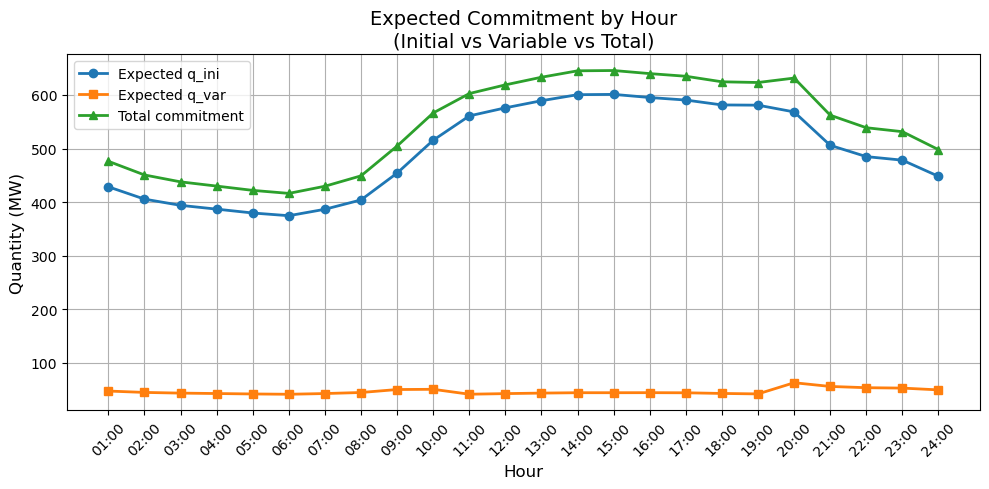

In [166]:
sel_block = {
    t: next(b for b in range(B_full) if u[t,b].X > 0.5)
    for t in T
}

# --- (다) 기대 q_ini, 기대 q_var 계산 -----------------------------
qini_exp = []
qvar_exp = []
for t in T:
    b = sel_block[t]
    # 시나리오별 qini, qvar 값을 뽑아와서 평균(기대) 계산
    qini_vals = [ qini[(s,t,b)]            for s in scenarios ]
    qvar_vals = [ qvar[(s,t,b)].X         for s in scenarios ]
    qini_exp.append( sum(qini_vals)*p_s )
    qvar_exp.append( sum(qvar_vals)*p_s )

# --- (라) 합계 커밋 총량 -------------------------------------------
total_commit = [qini_exp[i] + qvar_exp[i] for i in range(len(T))]

# --- (마) 시각화 --------------------------------------------------
plt.figure(figsize=(10,5))
plt.plot(T, qini_exp,    'o-', label='Expected q_ini',  linewidth=2)
plt.plot(T, qvar_exp,    's-', label='Expected q_var',  linewidth=2)
plt.plot(T, total_commit,'^-', label='Total commitment', linewidth=2)
plt.xticks(T, [f"{h:02d}:00" for h in T], rotation=45)
plt.xlabel("Hour", fontsize=12)
plt.ylabel("Quantity (MW)", fontsize=12)
plt.title("Expected Commitment by Hour\n(Initial vs Variable vs Total)", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [147]:


# # 예: T = [1,2,...,24], B_full = 최대 블록 개수(예: 10)
# T      = list(range(1,25))
# B_full = 10

# # 이미 stepwise 계산 단계에서 얻어둔 dict:
# #   qini[(t,b)], qmax[(t,b)], lambda_da_block[(t,b)]
# # 에는 “존재하는” (t,b) 조합만 채워져 있다고 가정합니다.

# # 1) 각 t별로 실제 존재하는 블록 목록을 뽑아둡니다.
# valid_blocks = {
#     t: [b for b in range(B_full) if (t,b) in qmax and qmax[(t,b)] > 0]
#     for t in T
# }

# # 2) 모델 생성
# m = gp.Model("WF_DA_LDR_reduced")

# # 3) 변수 선언: t별로 유효한 b만 생성
# u    = {}   # binary 선택 변수
# qvar = {}   # 연속 가변량 변수
# for t, blocks in valid_blocks.items():
#     for b in blocks:
#         u   [(t,b)] = m.addVar(vtype=GRB.BINARY, name=f"u_{t}_{b}")
#         qvar[(t,b)] = m.addVar(lb=0.0, name=f"qvar_{t}_{b}")

# # 4) Objective: 있는 (t,b)만 합산
# obj = gp.quicksum(
#     lambda_da_block[(t,b)] * (u[t,b]*qini[(t,b)] + qvar[t,b])
#     for t, blocks in valid_blocks.items()
#     for b in blocks
# )
# m.setObjective(obj, GRB.MAXIMIZE)

# # 5) Constraints
# for t, blocks in valid_blocks.items():
#     # (2c) 각 t에 대해 하나의 블록만 선택
#     m.addConstr(
#         gp.quicksum(u[t,b] for b in blocks) == 1,
#         name=f"one_block_{t}"
#     )
#     # (2d) qvar <= qmax * u
#     for b in blocks:
#         m.addConstr(
#             qvar[t,b] <= qmax[(t,b)] * u[t,b],
#             name=f"qvar_valid_{t}_{b}"
#         )

# # 6) 옵션 & 실행
# m.Params.TimeLimit  = 60
# m.Params.OutputFlag = 1
# m.optimize()

# # 7) 결과 확인
# if m.status in {GRB.OPTIMAL, GRB.TIME_LIMIT}:
#     print(f"Objective (DA profit): {m.ObjVal:.2f}")
#     for t, blocks in valid_blocks.items():
#         for b in blocks:
#             if u[t,b].X > 0.5:
#                 print(f"t={t}, block={b}, q_ini={qini[(t,b)]:.1f}, "
#                       f"q_var={qvar[t,b].X:.1f}, λ_da={lambda_da_block[(t,b)]:.2f}")


In [128]:
# # T, B는 그대로
# T = range(1,25)
# B = 10
# selected_date = '20250720'# 이미 “20~27일” 루프에서 period=1~24, day=20 일에 대해서 채워져 있다고 가정합니다.

# model = gp.Model("WF_20July_DA")

# # 변수 선언
# u    = model.addVars(T, range(B), vtype=GRB.BINARY, name="u")
# qvar = model.addVars(T, range(B), lb=0.0, name="qvar")

# # 목적함수: date 없이 (t,b) 만 사용
# obj = gp.quicksum(
#     lambda_da_block[(t,b)] * (u[t,b]*qini[(t,b)] + qvar[t,b])
#     for t in T
#     for b in range(B)
# )
# model.setObjective(obj, GRB.MAXIMIZE)

# # 제약조건
# for t in T:
#     # (2c) 하나의 block만 선택
#     model.addConstr(u.sum(t, "*") == 1, name=f"one_block_{t}")
#     for b in range(B):
#         # (2d) qvar ≤ qmax·u 
#         model.addConstr(
#             qvar[t,b] <= qmax[(t,b)] * u[t,b],
#             name=f"qvar_valid_{t}_{b}"
#         )

# # 옵션 & 최적화
# model.Params.TimeLimit  = 60
# model.Params.OutputFlag = 1
# model.optimize()

# # 결과 출력
# if model.status in {GRB.OPTIMAL, GRB.TIME_LIMIT}:
#     print(f"Day-Ahead obj (20Jul): {model.ObjVal:.2f}")
#     for t in T:
#         for b in range(B):
#             if u[t,b].X > 0.5:
#                 print(f" Hour {t:02d}: block {b}, "
#                       f"q_ini={qini[(t,b)]:.1f}, "
#                       f"q_var={qvar[t,b].X:.1f}, "
#                       f"λ_da={lambda_da_block[(t,b)]:.2f}")


Set parameter TimeLimit to value 60
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 264 rows, 480 columns and 710 nonzeros
Model fingerprint: 0x19c83760
Variable types: 240 continuous, 240 integer (240 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+03]
  Objective range  [2e-03, 2e+06]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective -1.28373e+07


Presolve removed 264 rows and 480 columns
Presolve time: 0.01s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 1 (of 32 available processors)

Solution count 2: 2.87916e+06 -1.28373e+07 

Optimal solution found (tolerance 1.00e-04)
Best objective 2.879158288492e+06, best bound 2.879158288492e+06, gap 0.0000%
Day-Ahead obj (20Jul): 2879158.29
 Hour 01: block 1, q_ini=4740.0, q_var=4740.0, λ_da=43.71
 Hour 02: block 1, q_ini=4740.0, q_var=4740.0, λ_da=39.31
 Hour 03: block 1, q_ini=4740.0, q_var=4740.0, λ_da=40.01
 Hour 04: block 1, q_ini=4740.0, q_var=4740.0, λ_da=38.90
 Hour 05: block 0, q_ini=0.0, q_var=4740.0, λ_da=51.28
 Hour 06: block 0, q_ini=0.0, q_var=4740.0, λ_da=50.12
 Hour 07: block 0, q_ini=0.0, q_var=4740.0, λ_da=50.19
 Hour 08: block 0, q_ini=0.0, q_var=4740.0, λ_da=36.70
 Hour 09: block 0, q_ini=0.0, q_var=4740.0, λ_da=2.77
 Hour 10: block 0, q_ini=0.0, q_var=0.0, λ_da=-0.26
 Hour 11: block

### 시각화

In [150]:
from scipy.optimize import root_scalar


In [148]:
# import matplotlib.pyplot as plt

# # 1) 결과 수집: t별로 선택된 block과 q_ini, q_var
# commit_init = {}
# commit_var  = {}
# chosen_block = {}

# for t, blocks in valid_blocks.items():
#     # 이 시간대에 선택된 블록 b*
#     b_star = next(b for b in blocks if u[t,b].X > 0.5)
#     chosen_block[t] = b_star

#     # 초기량 & 가변량
#     init_q = qini[(t, b_star)]
#     var_q  = qvar[t, b_star].X

#     commit_init[t] = init_q
#     commit_var [t] = var_q

# # 2) Stacked bar로 시각화
# hours = list(commit_init.keys())
# init_vals = [commit_init[t] for t in hours]
# var_vals  = [commit_var [t] for t in hours]

# plt.figure(figsize=(10,5))
# plt.bar(hours, init_vals, label='Initial block quantity', alpha=0.7)
# plt.bar(hours, var_vals, bottom=init_vals, label='Variable quantity', alpha=0.7)
# plt.xlabel('Hour (Period)', fontsize=12)
# plt.ylabel('Committed Quantity (MW)', fontsize=12)
# plt.title(f'Day-Ahead Commitment by Hour for {date_str}', fontsize=14)
# plt.xticks(hours)
# plt.legend()
# plt.grid(axis='y', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()


In [149]:

# from scipy.optimize import root_scalar

# # 0) 7/20일 데이터 불러오기
# date_str = "20250720"
# df20 = pd.read_csv(f"filteredcurve_{date_str}.csv", encoding='utf-8-sig')

# # 1) 최적화 결과에서 커밋량 가져오기 (예전에 계산한 commit_init, commit_var)
# #    commit[t] = commit_init[t] + commit_var[t]
# #    여기서는 이미 commit 딕셔너리가 있다고 가정합니다.
# #    예: commit = {1: 120.0, 2:  80.0, …, 24: 200.0}

# # 2) 시간대별 supply, demand 함수 준비
# orig_cp = {}   # q=0 일 때 original clearing price
# new_cp  = {}   # q=commit 일 때 new clearing price

# for t in range(1,25):
#     sub  = df20[df20['Time Period']==t]
#     sup  = sub[sub['GC']=='V']
#     dem  = sub[sub['GC']=='C']
#     if sup.empty or dem.empty:
#         orig_cp[t] = np.nan
#         new_cp [t] = np.nan
#         continue

#     # 집계 → 누적
#     s_agg = ( sup.groupby('Price')['Amount'].sum()
#                  .reset_index().sort_values('Price') )
#     s_agg['CumulQty'] = s_agg['Amount'].cumsum()
#     d_agg = ( dem.groupby('Price')['Amount'].sum()
#                  .reset_index().sort_values('Price') )
#     d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

#     # 계단형 보간 함수
#     s_f = interp1d(s_agg['Price'], s_agg['CumulQty'],
#                    kind='previous', bounds_error=False,
#                    fill_value=(0, s_agg['CumulQty'].iat[-1]))
#     d_f = interp1d(d_agg['Price'], d_agg['CumulQty'],
#                    kind='previous', bounds_error=False,
#                    fill_value=(d_agg['CumulQty'].iat[0], 0))

#     # price grid 설정
#     pmin = min(s_agg['Price'].min(), d_agg['Price'].min())
#     pmax = max(s_agg['Price'].max(), d_agg['Price'].max())
#     price_grid = np.linspace(pmin, pmax, 500)

#     # 수요·공급 누적량
#     sv = s_f(price_grid)
#     dv = d_f(price_grid)

#     # (a) 원래 clearing price: D(p)-S(p)=0
#     sol0 = root_scalar(
#         lambda p: np.interp(p, price_grid, dv) - np.interp(p, price_grid, sv),
#         bracket=[pmin, pmax], method='bisect'
#     )
#     orig_cp[t] = sol0.root if sol0.converged else np.nan

#     # (b) new clearing price: D(p)-S(p)-commit[t]=0
#     q_commit = commit[t]  # optimization 후 커밋된 양
#     sol1 = root_scalar(
#         lambda p: np.interp(p, price_grid, dv)
#                   - np.interp(p, price_grid, sv)
#                   - q_commit,
#         bracket=[pmin, pmax], method='bisect'
#     )
#     new_cp[t] = sol1.root if sol1.converged else np.nan

# # 3) 시각화
# hours     = list(range(1,25))
# orig_vals = [orig_cp[t] for t in hours]
# new_vals  = [new_cp [t] for t in hours]

# plt.figure(figsize=(10,5))
# plt.plot(hours, orig_vals, 'o-', label='Original Clearing Price (q=0)',
#          linewidth=1, alpha=0.8)
# plt.plot(hours, new_vals,  's-', label='New Clearing Price (after commit)',
#          linewidth=1, alpha=0.8)

# plt.xlabel('Hour (Period)', fontsize=12)
# plt.ylabel('Clearing Price (€/MWh)', fontsize=12)
# plt.title(f'Original vs. New Clearing Prices by Hour for {date_str}', fontsize=14)
# plt.xticks(hours)
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()
